In [76]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from prophet.plot import plot_plotly, plot_components_plotly
from prophet import Prophet
from sqlalchemy import create_engine

In [77]:
# Load and Clean the Data

In [78]:
TRAIN_FILE = "fraudTrain.csv"
TEST_FILE = "fraudTest.csv"

In [79]:
train = pd.read_csv("D:\Data Analytics\Projects\FinSights/fraudTrain.csv", index_col=0)
test = pd.read_csv("D:\Data Analytics\Projects\FinSights/fraudTest.csv", index_col=0)

df = pd.concat([train, test], ignore_index=True)
print(f"Total rows loaded: {len(df):,}")
print(f"Columns: {list(df.columns)}")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\ashwi\AppData\Local\Temp\ipykernel_23768\3946093966.py:1: SyntaxWarning: invalid escape sequence '\D'
  train = pd.read_csv("D:\Data Analytics\Projects\FinSights/fraudTrain.csv", index_col=0)
C:\Users\ashwi\AppData\Local\Temp\ipykernel_23768\3946093966.py:2: SyntaxWarning: invalid escape sequence '\D'
  test = pd.read_csv("D:\Data Analytics\Projects\FinSights/fraudTest.csv", index_col=0)


Total rows loaded: 1,852,394
Columns: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [80]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [81]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["trans_year"]  = df["trans_date_trans_time"].dt.year
df["trans_month"] = df["trans_date_trans_time"].dt.month
df["trans_day"]   = df["trans_date_trans_time"].dt.day
df["trans_hour"]  = df["trans_date_trans_time"].dt.hour
df["trans_dow"]   = df["trans_date_trans_time"].dt.day_name()
df["trans_date"]  = df["trans_date_trans_time"].dt.date.astype(str)

In [82]:
df["dob"] = pd.to_datetime(df["dob"])
df["age"] = ((df["trans_date_trans_time"] - df["dob"]).dt.days / 365).astype(int)

In [83]:
bins   = [0, 25, 35, 50, 65, 120]
labels = ["<25", "25-35", "35-50", "50-65", "65+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

In [84]:
print(f'Missing Values: {df.isnull().sum().sum()}')
print(f"Duplicates: {df.duplicated().sum()}")

Missing Values: 0
Duplicates: 0


In [85]:
print(train.head())

  trans_date_trans_time            cc_num                            merchant  \
0   2019-01-01 00:00:18  2703186189652095          fraud_Rippin, Kub and Mann   
1   2019-01-01 00:00:44      630423337322     fraud_Heller, Gutmann and Zieme   
2   2019-01-01 00:00:51    38859492057661                fraud_Lind-Buckridge   
3   2019-01-01 00:01:16  3534093764340240  fraud_Kutch, Hermiston and Farrell   
4   2019-01-01 00:03:06   375534208663984                 fraud_Keeling-Crist   

        category     amt      first     last gender  \
0       misc_net    4.97   Jennifer    Banks      F   
1    grocery_pos  107.23  Stephanie     Gill      F   
2  entertainment  220.11     Edward  Sanchez      M   
3  gas_transport   45.00     Jeremy    White      M   
4       misc_pos   41.96      Tyler   Garcia      M   

                         street            city  ...      lat      long  \
0                561 Perry Cove  Moravian Falls  ...  36.0788  -81.1781   
1  43039 Riley Greens Suite 393 

In [86]:
print(test.head())

  trans_date_trans_time            cc_num  \
0   2020-06-21 12:14:25  2291163933867244   
1   2020-06-21 12:14:33  3573030041201292   
2   2020-06-21 12:14:53  3598215285024754   
3   2020-06-21 12:15:15  3591919803438423   
4   2020-06-21 12:15:17  3526826139003047   

                               merchant        category    amt   first  \
0                 fraud_Kirlin and Sons   personal_care   2.86    Jeff   
1                  fraud_Sporer-Keebler   personal_care  29.84  Joanne   
2  fraud_Swaniawski, Nitzsche and Welch  health_fitness  41.28  Ashley   
3                     fraud_Haley Group        misc_pos  60.05   Brian   
4                 fraud_Johnston-Casper          travel   3.19  Nathan   

       last gender                       street        city  ...      lat  \
0   Elliott      M            351 Darlene Green    Columbia  ...  33.9659   
1  Williams      F             3638 Marsh Union     Altonah  ...  40.3207   
2     Lopez      F         9333 Valentine Point    Be

In [87]:
# EDA

In [88]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight"})
COLORS = sns.color_palette("muted", 12)
OUTPUT = "outputs/"
import os; os.makedirs(OUTPUT, exist_ok=True)

In [89]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["trans_month_dt"] = pd.to_datetime(
    df["trans_year"].astype(str) + "-" + df["trans_month"].astype(str).str.zfill(2)
)

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

Rows: 1,852,394  |  Columns: 31
trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                      datetime64[ns]
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
trans_year                        int32
trans_month                       int32
trans_da

In [90]:
# Dataset overview stats
print("\n--- Dataset Summary ---")
print(f"Date range   : {df['trans_date'].min()} → {df['trans_date'].max()}")
print(f"Unique customers : {df['cc_num'].nunique():,}")
print(f"Unique merchants : {df['merchant'].nunique():,}")
print(f"Categories   : {df['category'].nunique()}")
print(f"Total spend  : ${df['amt'].sum():,.2f}")
print(f"Fraud txns   : {df['is_fraud'].sum():,} ({df['is_fraud'].mean()*100:.2f}%)")


--- Dataset Summary ---
Date range   : 2019-01-01 → 2020-12-31
Unique customers : 999
Unique merchants : 693
Categories   : 14
Total spend  : $129,785,332.01
Fraud txns   : 9,651 (0.52%)


In [91]:
# Monthly transaction volume & revenue

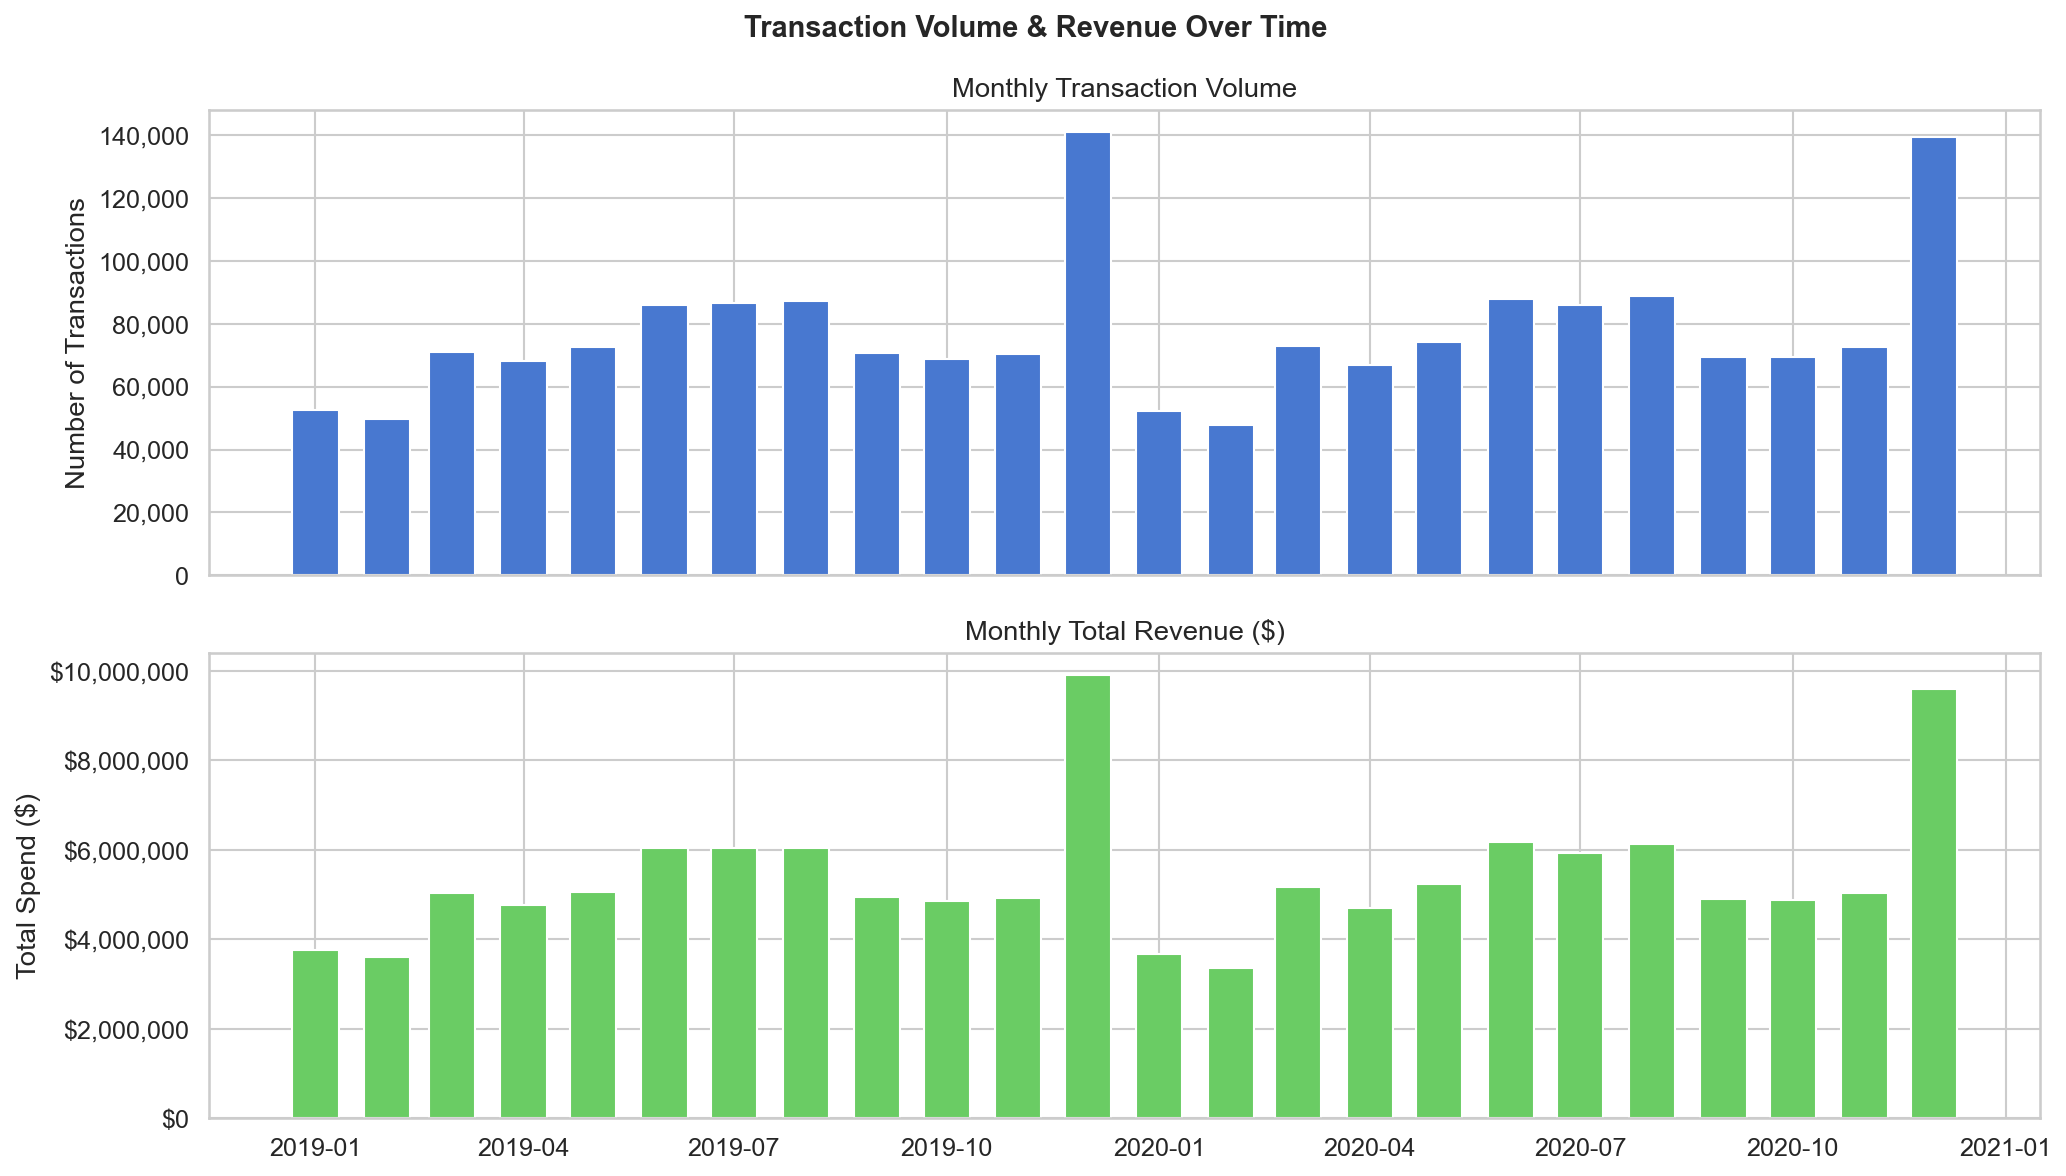

Saved: plot1_monthly_trend.png


In [92]:
monthly = df.groupby("trans_month_dt").agg(
    txn_count=("amt", "count"),
    total_spend=("amt", "sum")
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].bar(monthly["trans_month_dt"], monthly["txn_count"], color=COLORS[0], width=20)
axes[0].set_title("Monthly Transaction Volume")
axes[0].set_ylabel("Number of Transactions")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[1].bar(monthly["trans_month_dt"], monthly["total_spend"], color=COLORS[2], width=20)
axes[1].set_title("Monthly Total Revenue ($)")
axes[1].set_ylabel("Total Spend ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.suptitle("Transaction Volume & Revenue Over Time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT}plot1_monthly_trend.png")
plt.show()
print("Saved: plot1_monthly_trend.png")

In [93]:
# Transaction amount distribution (log scale)

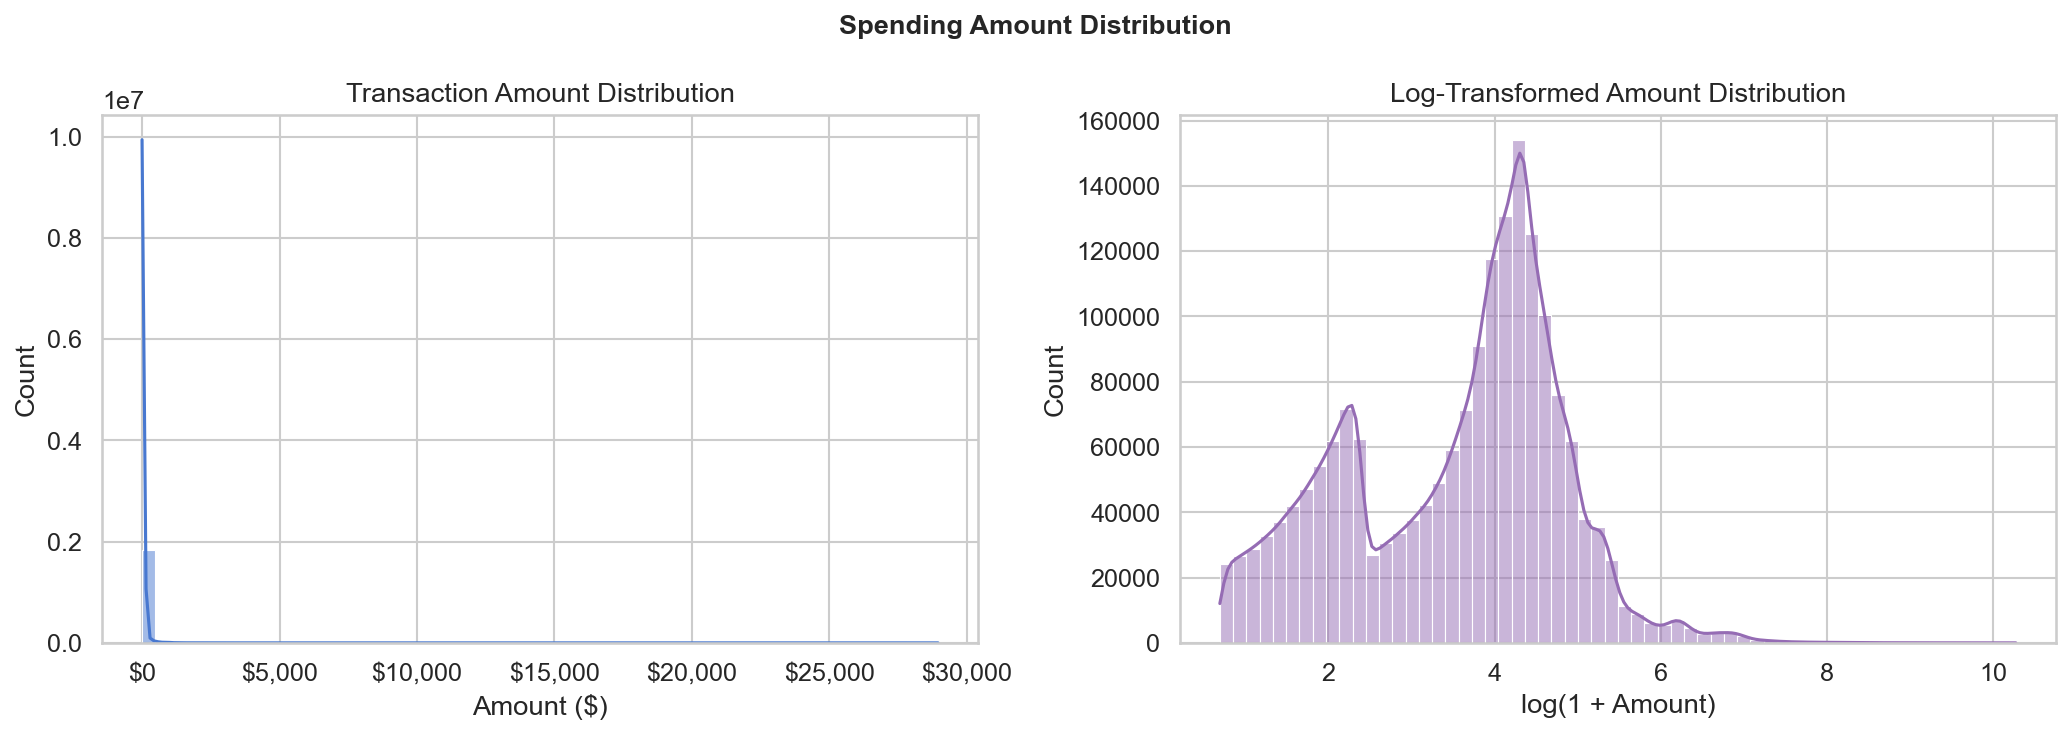

Saved: plot2_amount_dist.png


In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["amt"], bins=60, kde=True, color=COLORS[0], ax=axes[0])
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("Amount ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

sns.histplot(np.log1p(df["amt"]), bins=60, kde=True, color=COLORS[4], ax=axes[1])
axes[1].set_title("Log-Transformed Amount Distribution")
axes[1].set_xlabel("log(1 + Amount)")

plt.suptitle("Spending Amount Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT}plot2_amount_dist.png")
plt.show()
print("Saved: plot2_amount_dist.png")

In [95]:
# Category-wise total spend (horizontal bar)

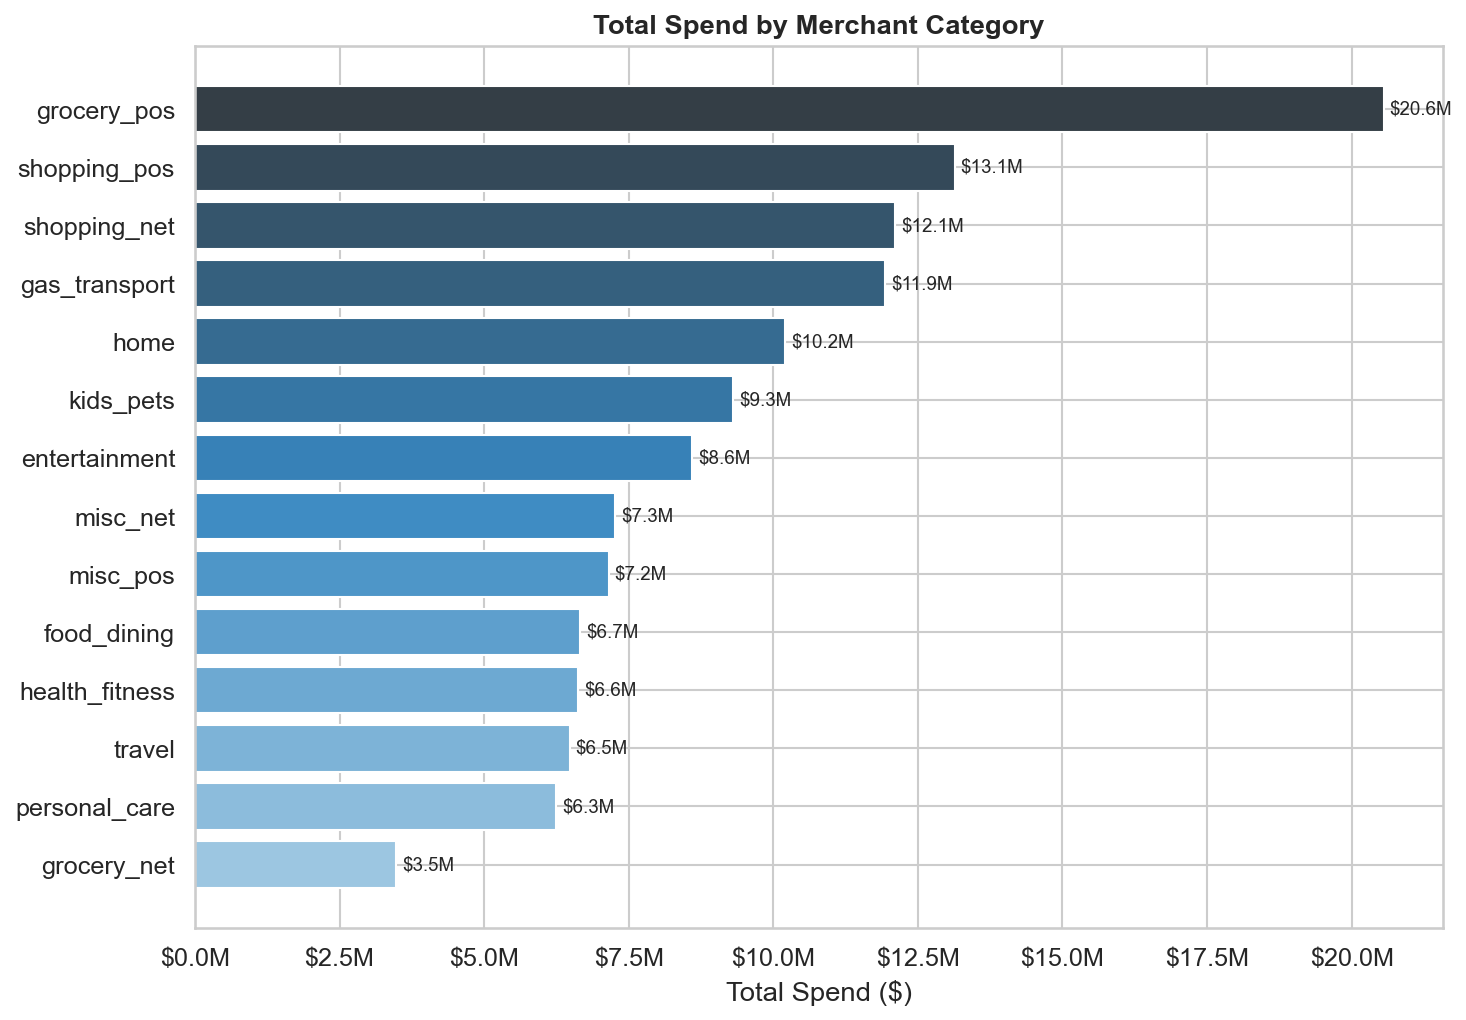

Saved: plot3_category_spend.png


In [96]:
cat_spend = (df.groupby("category")["amt"]
               .sum()
               .sort_values(ascending=True)
               .reset_index())

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(cat_spend["category"], cat_spend["amt"],
               color=sns.color_palette("Blues_d", len(cat_spend)))
ax.set_xlabel("Total Spend ($)")
ax.set_title("Total Spend by Merchant Category", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
for bar, val in zip(bars, cat_spend["amt"]):
    ax.text(val + 1e5, bar.get_y() + bar.get_height()/2,
            f"${val/1e6:.1f}M", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT}plot3_category_spend.png")
plt.show()
print("Saved: plot3_category_spend.png")

In [97]:
# Hourly heatmap (spend by hour × day of week)

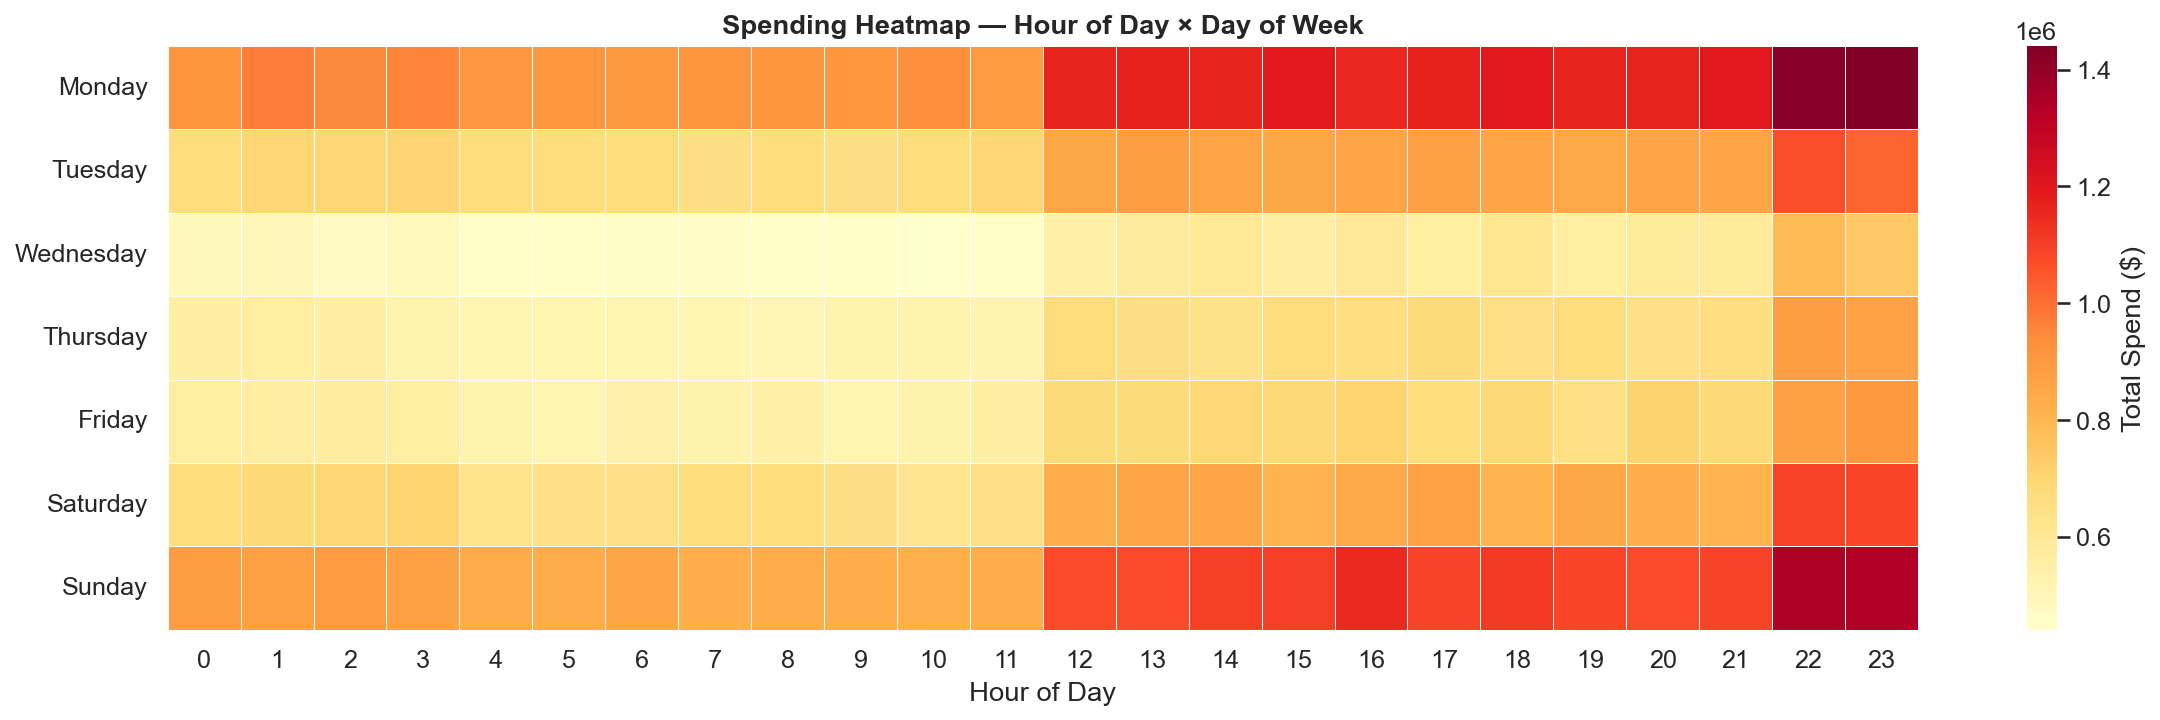

Saved: plot4_heatmap_dow_hour.png


In [98]:
DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = (df.groupby(["trans_dow","trans_hour"])["amt"]
           .sum()
           .unstack()
           .reindex(DOW_ORDER))

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            fmt=".0f", ax=ax, cbar_kws={"label": "Total Spend ($)"})
ax.set_title("Spending Heatmap — Hour of Day × Day of Week", fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{OUTPUT}plot4_heatmap_dow_hour.png")
plt.show()
print("Saved: plot4_heatmap_dow_hour.png")


In [99]:
# Fraud vs Non-Fraud amount boxplot by category

C:\Users\ashwi\AppData\Local\Temp\ipykernel_23768\551499776.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


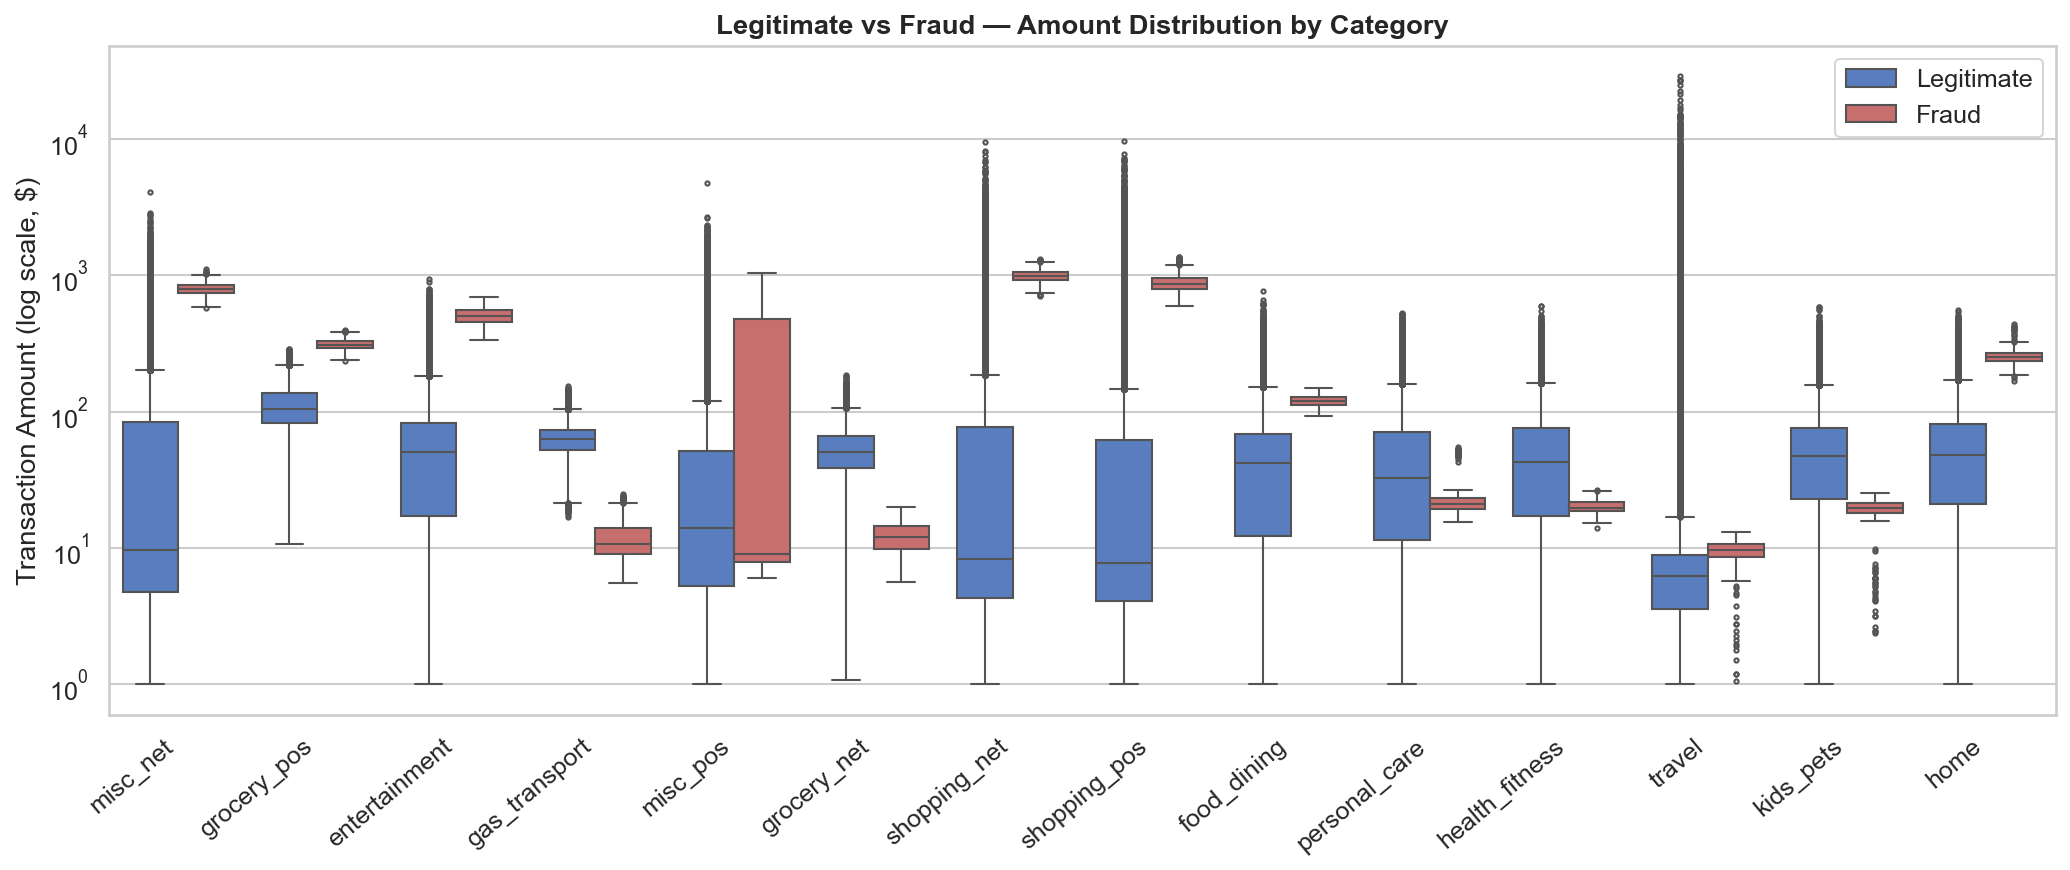

Saved: plot5_fraud_boxplot.png


In [100]:
df["fraud_label"] = df["is_fraud"].map({0: "Legitimate", 1: "Fraud"})

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x="category", y="amt", hue="fraud_label",
            palette={"Legitimate": COLORS[0], "Fraud": COLORS[3]},
            fliersize=2, ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Transaction Amount (log scale, $)")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
ax.set_title("Legitimate vs Fraud — Amount Distribution by Category", fontweight="bold")
ax.legend(title="")
plt.tight_layout()
plt.savefig(f"{OUTPUT}plot5_fraud_boxplot.png")
plt.show()
print("Saved: plot5_fraud_boxplot.png")

In [101]:
# Fraud rate by category (bar)

C:\Users\ashwi\AppData\Local\Temp\ipykernel_23768\160179418.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


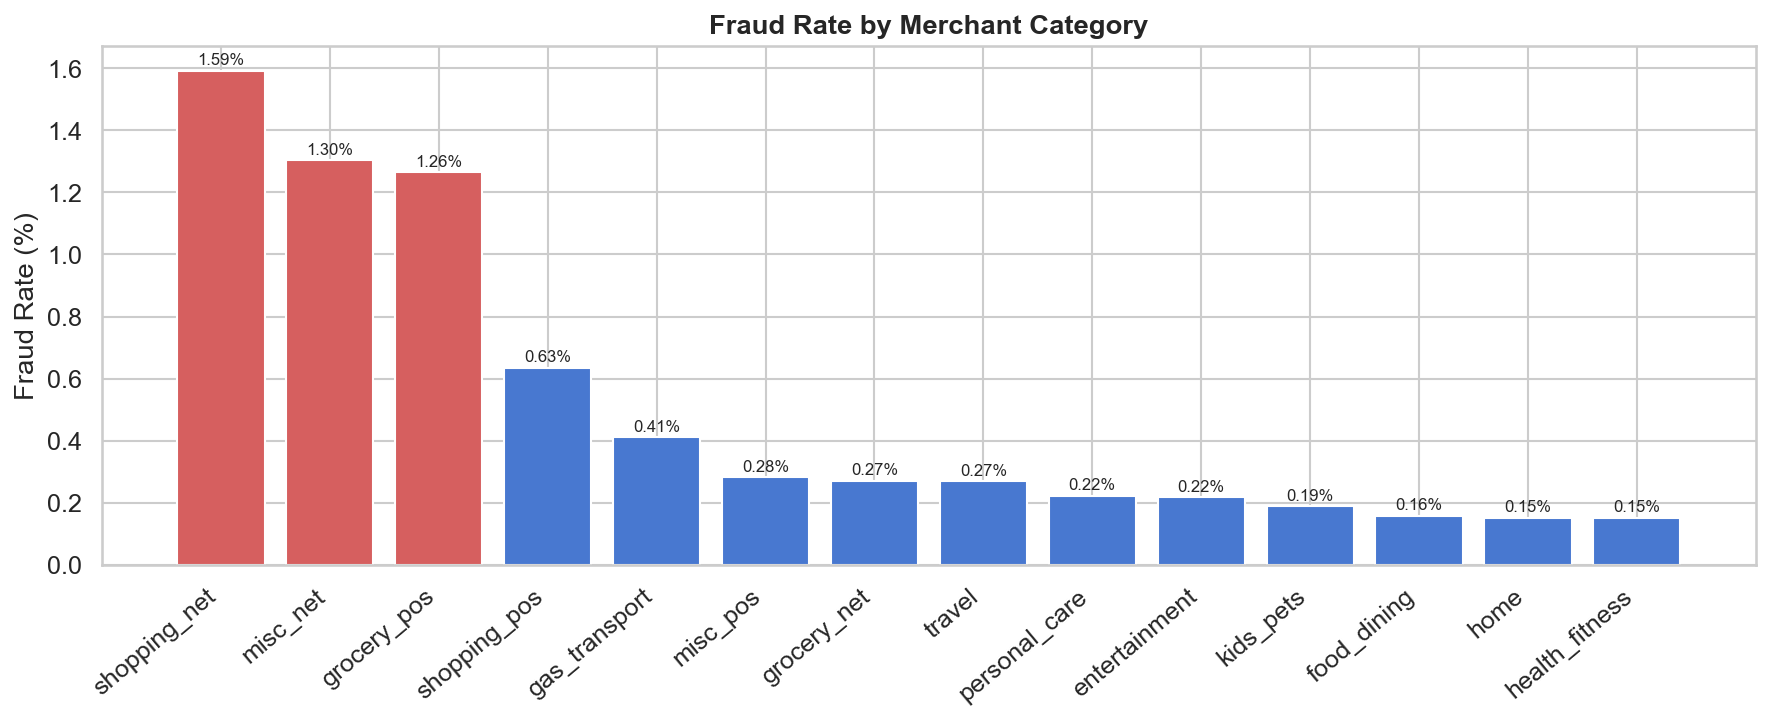

Saved: plot6_fraud_rate_by_category.png


In [102]:
fraud_rate = (df.groupby("category")
                .agg(fraud_rate=("is_fraud","mean"),
                     txn_count=("is_fraud","count"))
                .reset_index()
                .sort_values("fraud_rate", ascending=False))
fraud_rate["fraud_rate_pct"] = fraud_rate["fraud_rate"] * 100

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(fraud_rate["category"], fraud_rate["fraud_rate_pct"],
              color=[COLORS[3] if r > 0.7 else COLORS[0] for r in fraud_rate["fraud_rate_pct"]])
ax.set_ylabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Merchant Category", fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
for bar, val in zip(bars, fraud_rate["fraud_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT}plot6_fraud_rate_by_category.png")
plt.show()
print("Saved: plot6_fraud_rate_by_category.png")

In [103]:
# Age group analysis

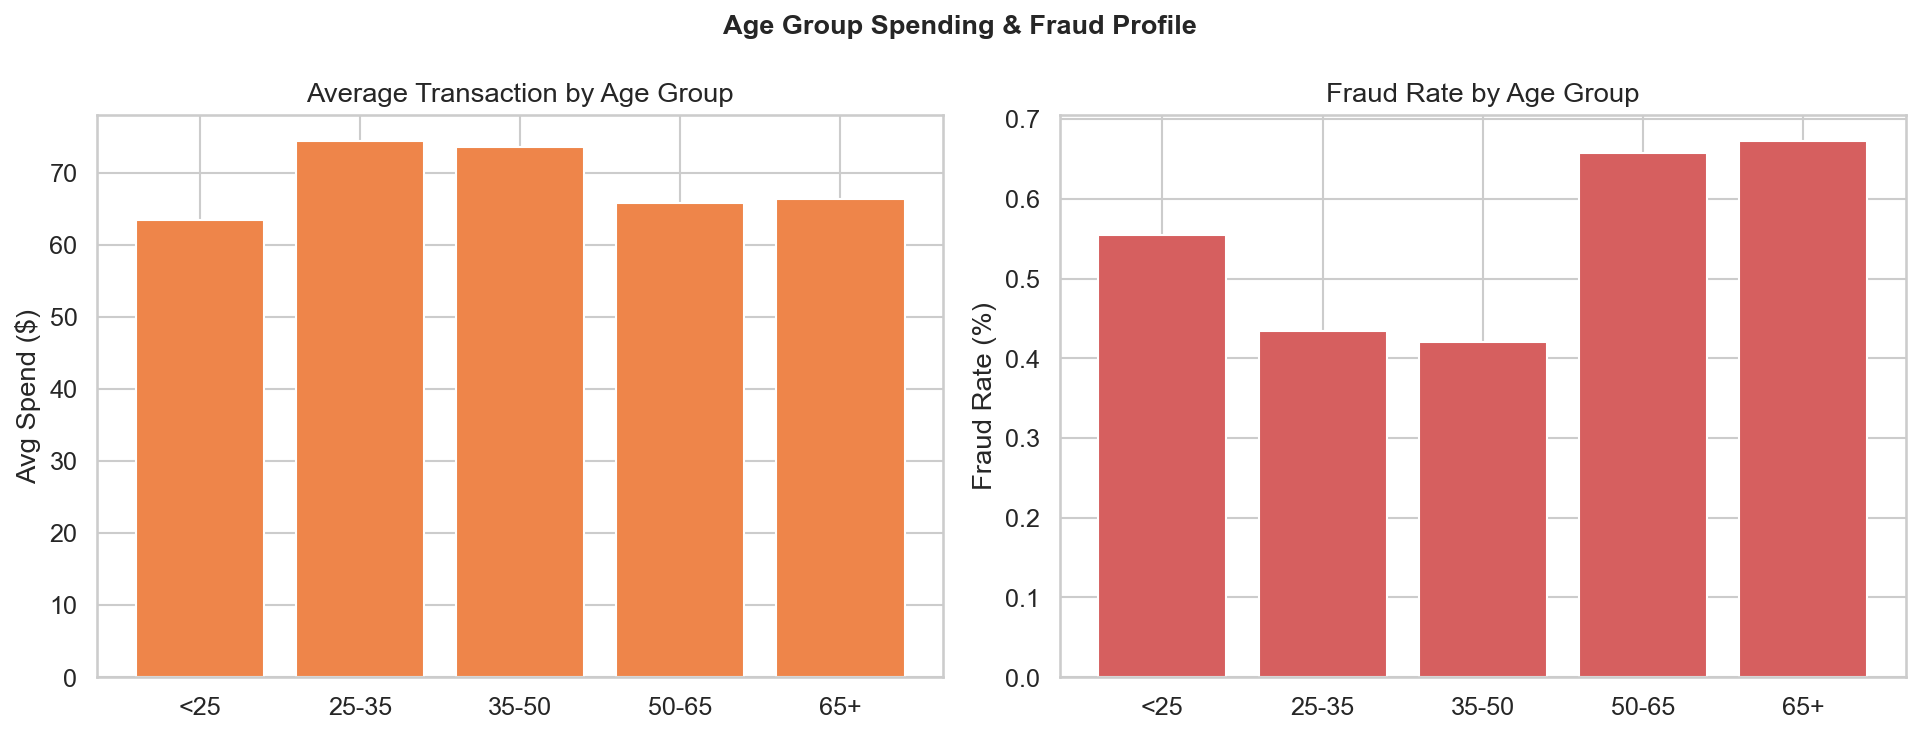

Saved: plot7_age_group.png


In [104]:
age_stats = (df.groupby("age_group", observed=True)
               .agg(avg_spend=("amt","mean"),
                    total_spend=("amt","sum"),
                    fraud_rate=("is_fraud","mean"))
               .reset_index())
age_stats["fraud_rate_pct"] = age_stats["fraud_rate"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(age_stats["age_group"].astype(str), age_stats["avg_spend"], color=COLORS[1])
axes[0].set_title("Average Transaction by Age Group")
axes[0].set_ylabel("Avg Spend ($)")

axes[1].bar(age_stats["age_group"].astype(str), age_stats["fraud_rate_pct"], color=COLORS[3])
axes[1].set_title("Fraud Rate by Age Group")
axes[1].set_ylabel("Fraud Rate (%)")

plt.suptitle("Age Group Spending & Fraud Profile", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT}plot7_age_group.png")
plt.show()
print("Saved: plot7_age_group.png")

In [105]:
# Gender spending comparison

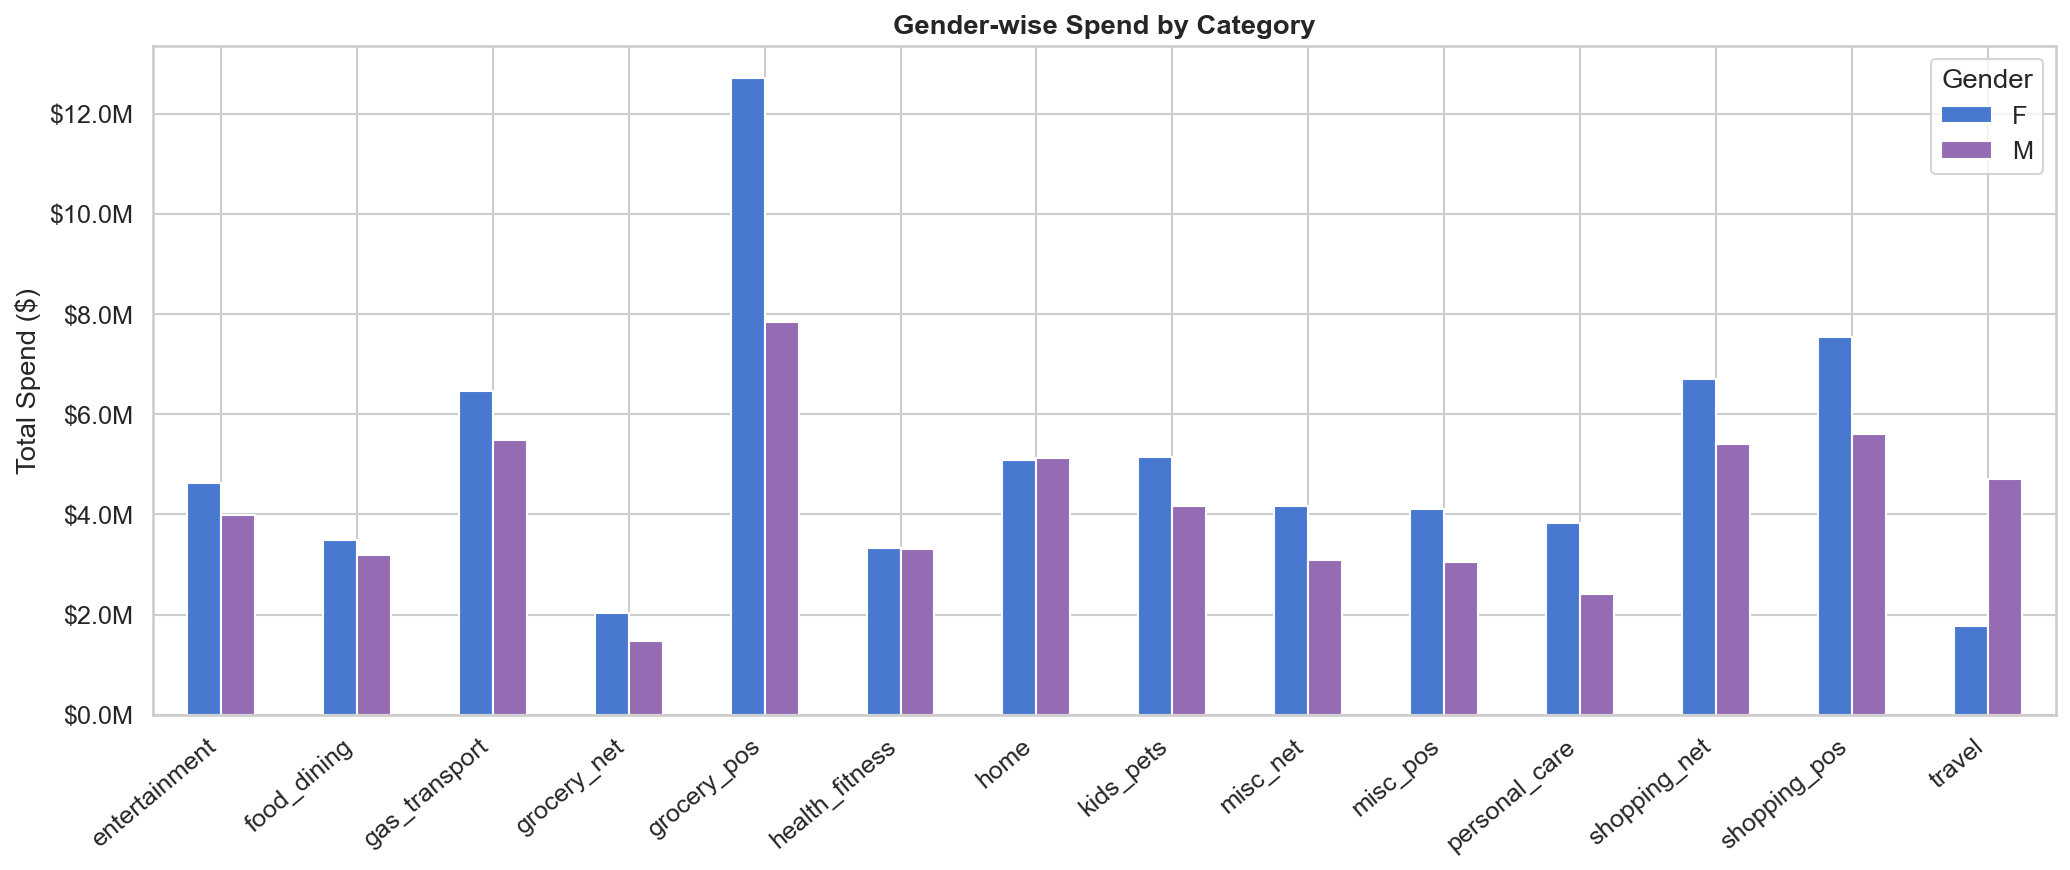

Saved: plot8_gender_category.png


In [106]:
gender_stats = df.groupby(["gender","category"]).agg(total_spend=("amt","sum")).reset_index()
pivot_g = gender_stats.pivot(index="category", columns="gender", values="total_spend").fillna(0)

pivot_g.plot(kind="bar", figsize=(14, 6), color=[COLORS[0], COLORS[4]])
plt.title("Gender-wise Spend by Category", fontweight="bold")
plt.ylabel("Total Spend ($)")
plt.xlabel("")
plt.xticks(rotation=40, ha="right")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
plt.legend(title="Gender")
plt.tight_layout()
plt.savefig(f"{OUTPUT}plot8_gender_category.png")
plt.show()
print("Saved: plot8_gender_category.png")

In [107]:
# Correlation heatmap (numeric features)

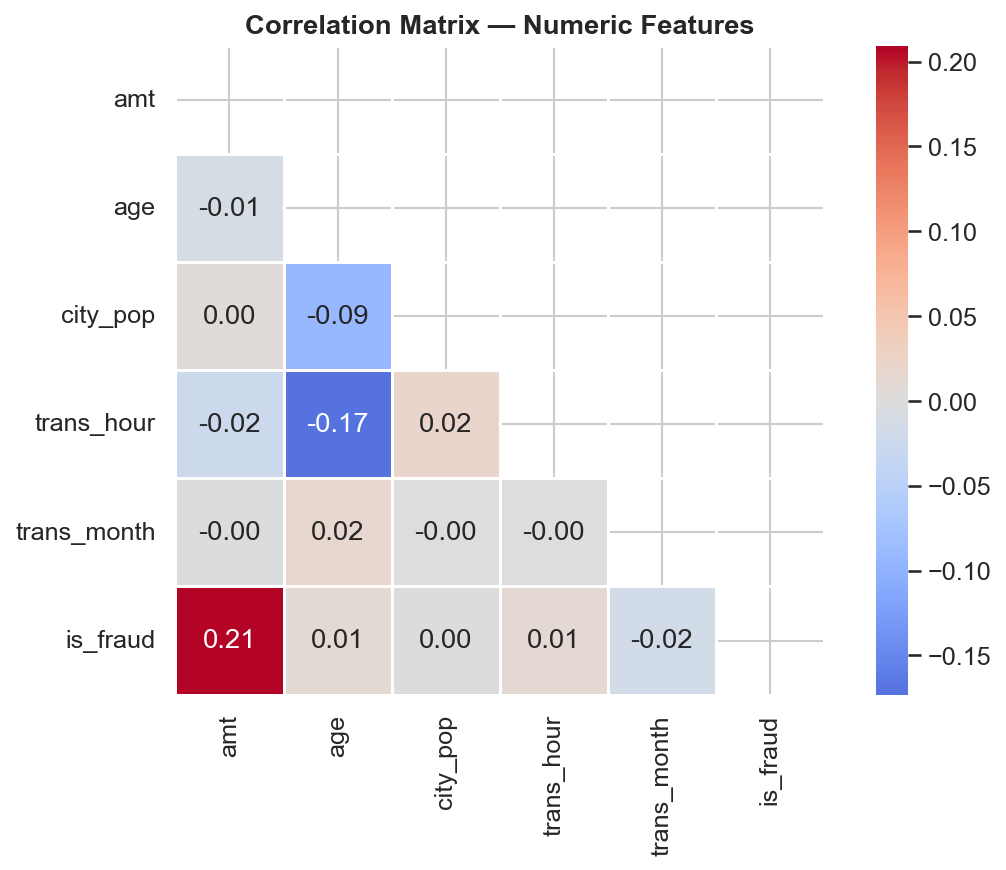

Saved: plot9_correlation.png

Step 2 complete — all EDA plots saved to outputs/


In [108]:
num_cols = ["amt","age","city_pop","trans_hour","trans_month","is_fraud"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, square=True,
            linewidths=0.5, linecolor="white")
ax.set_title("Correlation Matrix — Numeric Features", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT}plot9_correlation.png")
plt.show()
print("Saved: plot9_correlation.png")

print("\nStep 2 complete — all EDA plots saved to outputs/")

In [109]:
# RFM Customer Segmentation

In [110]:
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight"})
COLORS = sns.color_palette("Set2", 8)
OUTPUT = "outputs/"

In [111]:
df["trans_date"] = pd.to_datetime(df["trans_date"])
SNAPSHOT_DATE = df["trans_date"].max() + pd.Timedelta(days=1)
print(f"RFM snapshot date: {SNAPSHOT_DATE.date()}")
print(f"Legitimate transactions: {len(df):,}")

RFM snapshot date: 2021-01-01
Legitimate transactions: 1,852,394


In [112]:
# RFM table

In [113]:
rfm = df.groupby("cc_num").agg(
    last_txn     = ("trans_date", "max"),
    frequency    = ("trans_date", "count"),
    monetary     = ("amt",        "sum"),
    avg_txn      = ("amt",        "mean"),
    first_txn    = ("trans_date", "min"),
    categories   = ("category",   "nunique"),
).reset_index()

rfm["recency"] = (SNAPSHOT_DATE - rfm["last_txn"]).dt.days
rfm.rename(columns={"cc_num": "customer_id"}, inplace=True)

print(f"\nRFM table shape: {rfm.shape}")
print(rfm.describe().round(2))


RFM table shape: (999, 8)
        customer_id                       last_txn  frequency   monetary  \
count  9.990000e+02                            999     999.00     999.00   
mean   4.164321e+17  2020-11-24 00:00:00.000000256    1854.25  129915.25   
min    6.041621e+10            2019-01-03 00:00:00       6.00    1348.53   
25%    1.800375e+14            2020-12-31 00:00:00     740.00   57764.96   
50%    3.524485e+15            2020-12-31 00:00:00    1471.00  125001.32   
75%    4.652443e+15            2020-12-31 00:00:00    2917.00  179837.26   
max    4.992346e+18            2020-12-31 00:00:00    4392.00  411669.98   
std    1.303315e+18                            NaN    1175.57   85732.68   

       avg_txn                      first_txn  categories  recency  
count   999.00                            999      999.00   999.00  
mean    119.45  2019-01-30 18:34:14.054053888       13.18    38.00  
min      45.91            2019-01-01 00:00:00        2.00     1.00  
25%      61.

In [114]:
rfm["R"] = pd.qcut(rfm["recency"].rank(method="first"), q=5, labels=[5,4,3,2,1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), q=5, labels=[1,2,3,4,5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), q=5, labels=[1,2,3,4,5]).astype(int)

rfm["rfm_score"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)
rfm["rfm_total"] = rfm["R"] + rfm["F"] + rfm["M"]
rfm["rfm_avg_score"] = (rfm["rfm_total"] / 3).round(2)

In [115]:
def assign_segment(row):
    r, f, m = row["R"], row["F"], row["M"]
    score   = row["rfm_avg_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r <= 2 and f >= 4:
        return "At Risk"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost"
    elif r >= 3 and m >= 4:
        return "Potential Loyalist"
    elif r <= 2 and m >= 4:
        return "Cant Lose Them"
    else:
        return "Need Attention"

rfm["segment"] = rfm.apply(assign_segment, axis=1)

print("\nSegment distribution:")
seg_dist = rfm["segment"].value_counts()
print(seg_dist)


Segment distribution:
segment
Loyal Customers    224
Lost               208
Champions          168
Need Attention     158
New Customers      120
At Risk            107
Cant Lose Them      14
Name: count, dtype: int64


In [116]:
rfm.to_csv(f"{OUTPUT}rfm_table.csv", index=False)
print(f"\nRFM table saved → {OUTPUT}rfm_table.csv")


RFM table saved → outputs/rfm_table.csv


In [117]:
# Segment size (donut chart)

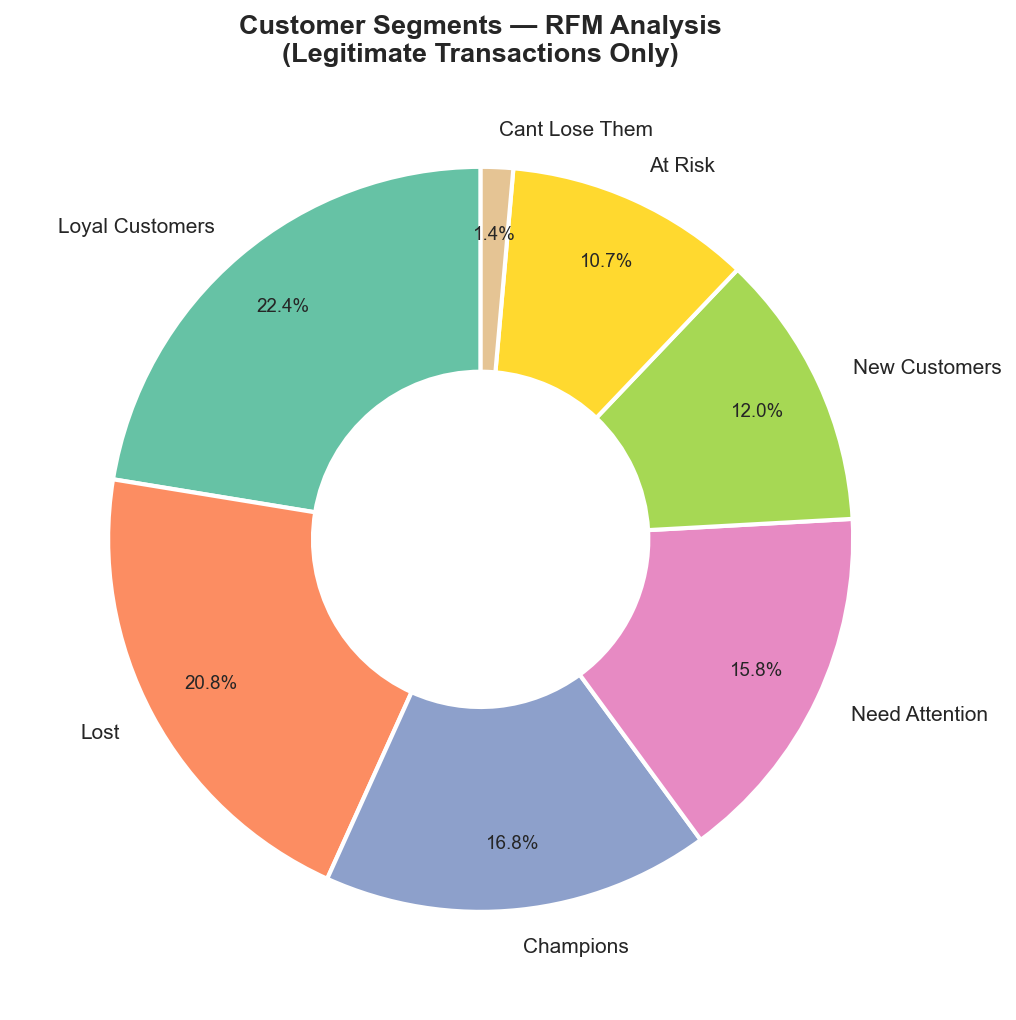

Saved: rfm_plot1_donut.png


In [118]:
seg_counts = rfm["segment"].value_counts()
palette    = sns.color_palette("Set2", len(seg_counts))

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct="%1.1f%%",
    colors=palette,
    pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    startangle=90
)
for t in texts:    t.set_fontsize(10)
for t in autotexts: t.set_fontsize(9)
ax.set_title("Customer Segments — RFM Analysis\n(Legitimate Transactions Only)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT}rfm_plot1_donut.png")
plt.show()
print("Saved: rfm_plot1_donut.png")

In [119]:
# Segment avg R, F, M heatmap (snake plot)

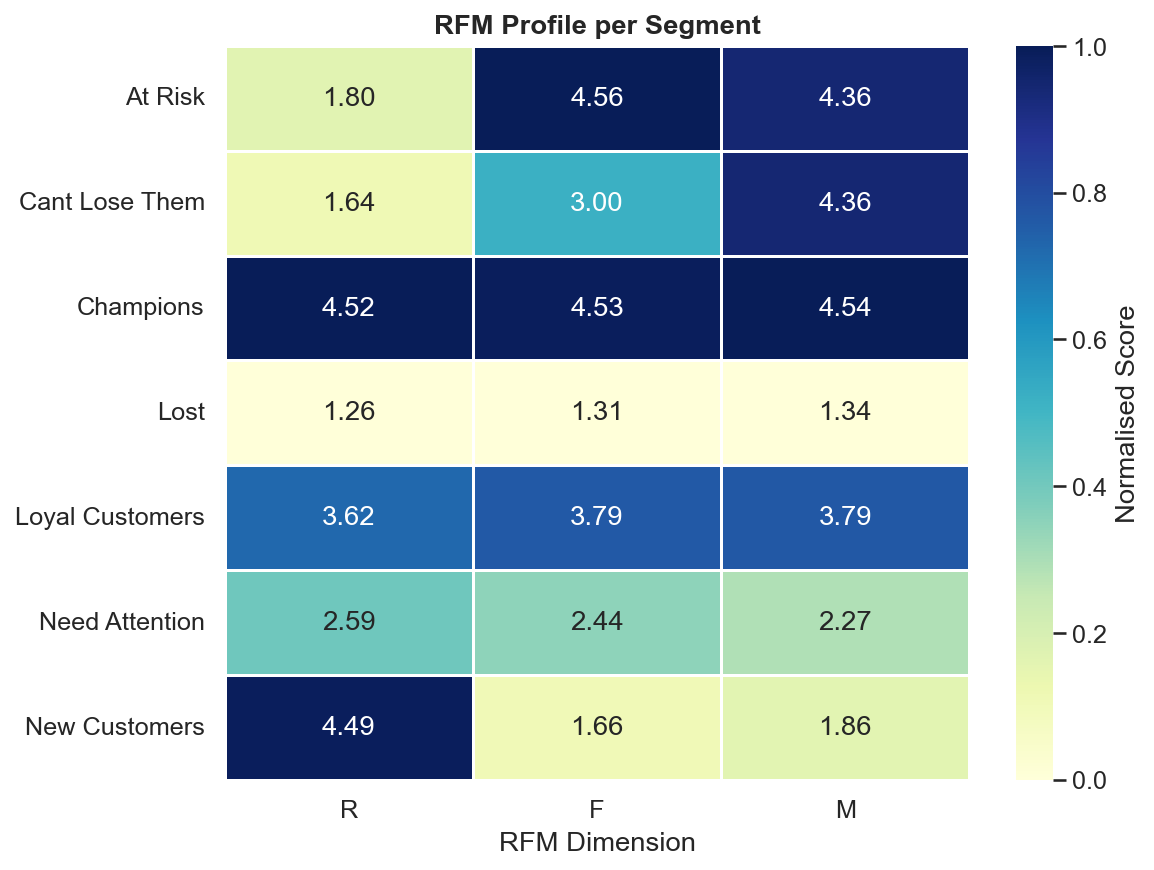

Saved: rfm_plot2_heatmap.png


In [120]:
seg_profile = rfm.groupby("segment")[["R","F","M","monetary","recency","frequency"]].mean().round(2)
seg_profile_norm = (seg_profile[["R","F","M"]] - seg_profile[["R","F","M"]].min()) / \
                   (seg_profile[["R","F","M"]].max() - seg_profile[["R","F","M"]].min())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(seg_profile_norm, annot=seg_profile[["R","F","M"]],
            fmt=".2f", cmap="YlGnBu", linewidths=0.5,
            linecolor="white", ax=ax, cbar_kws={"label": "Normalised Score"})
ax.set_title("RFM Profile per Segment", fontweight="bold")
ax.set_xlabel("RFM Dimension")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{OUTPUT}rfm_plot2_heatmap.png")
plt.show()
print("Saved: rfm_plot2_heatmap.png")

In [121]:
# Revenue contribution by segment

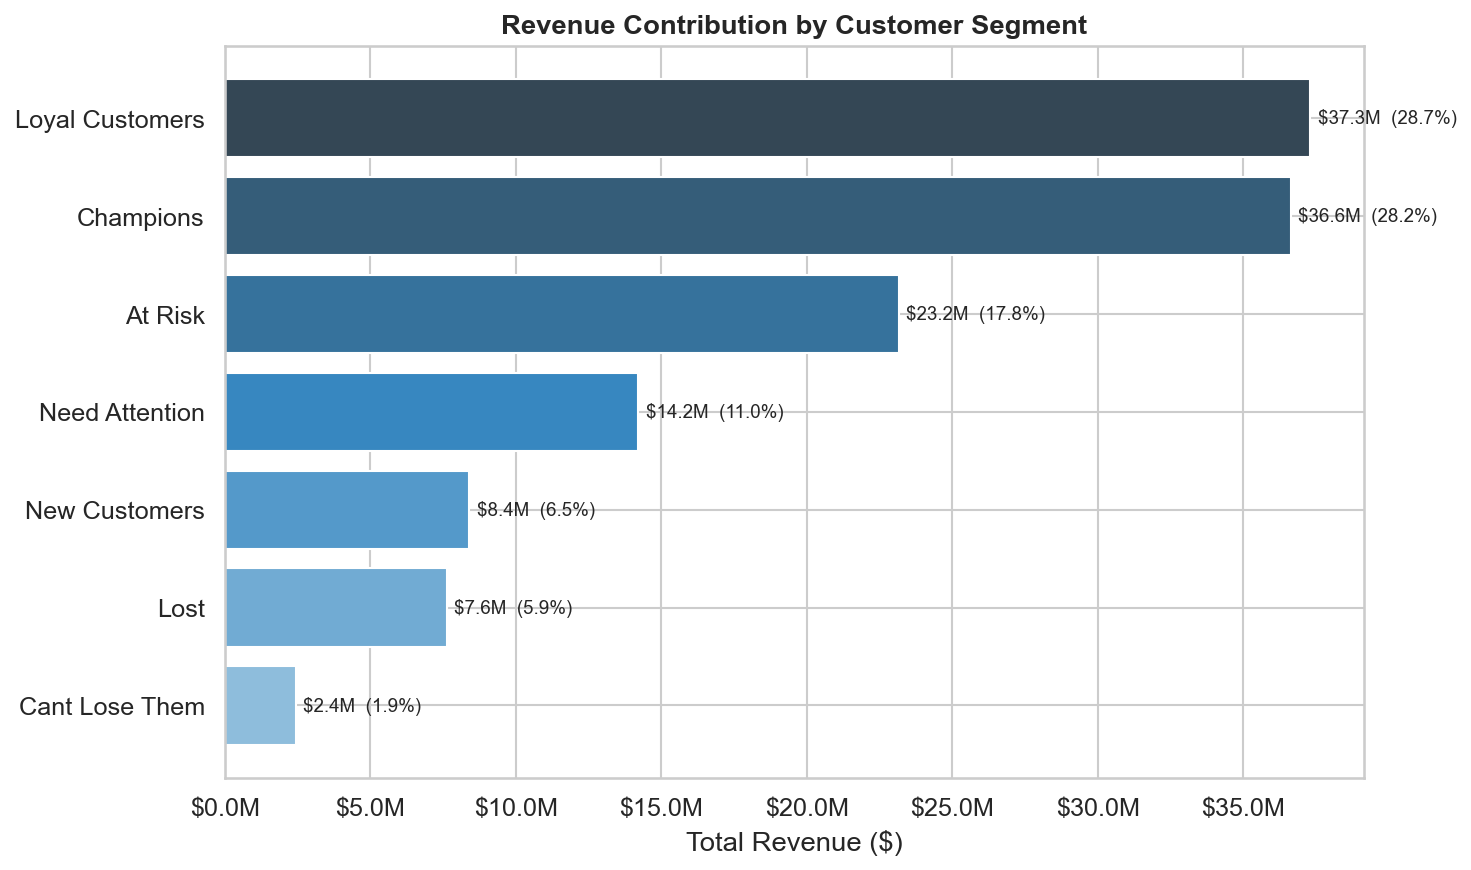

Saved: rfm_plot3_revenue.png


In [122]:
seg_revenue = rfm.groupby("segment")["monetary"].sum().sort_values(ascending=True)
total_rev   = seg_revenue.sum()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(seg_revenue.index, seg_revenue.values,
               color=sns.color_palette("Blues_d", len(seg_revenue)))
ax.set_xlabel("Total Revenue ($)")
ax.set_title("Revenue Contribution by Customer Segment", fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
for bar, val in zip(bars, seg_revenue.values):
    pct = val / total_rev * 100
    ax.text(val + total_rev*0.002, bar.get_y() + bar.get_height()/2,
            f"${val/1e6:.1f}M  ({pct:.1f}%)", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT}rfm_plot3_revenue.png")
plt.show()
print("Saved: rfm_plot3_revenue.png")

In [123]:
# Recency vs Monetary scatter, coloured by segment

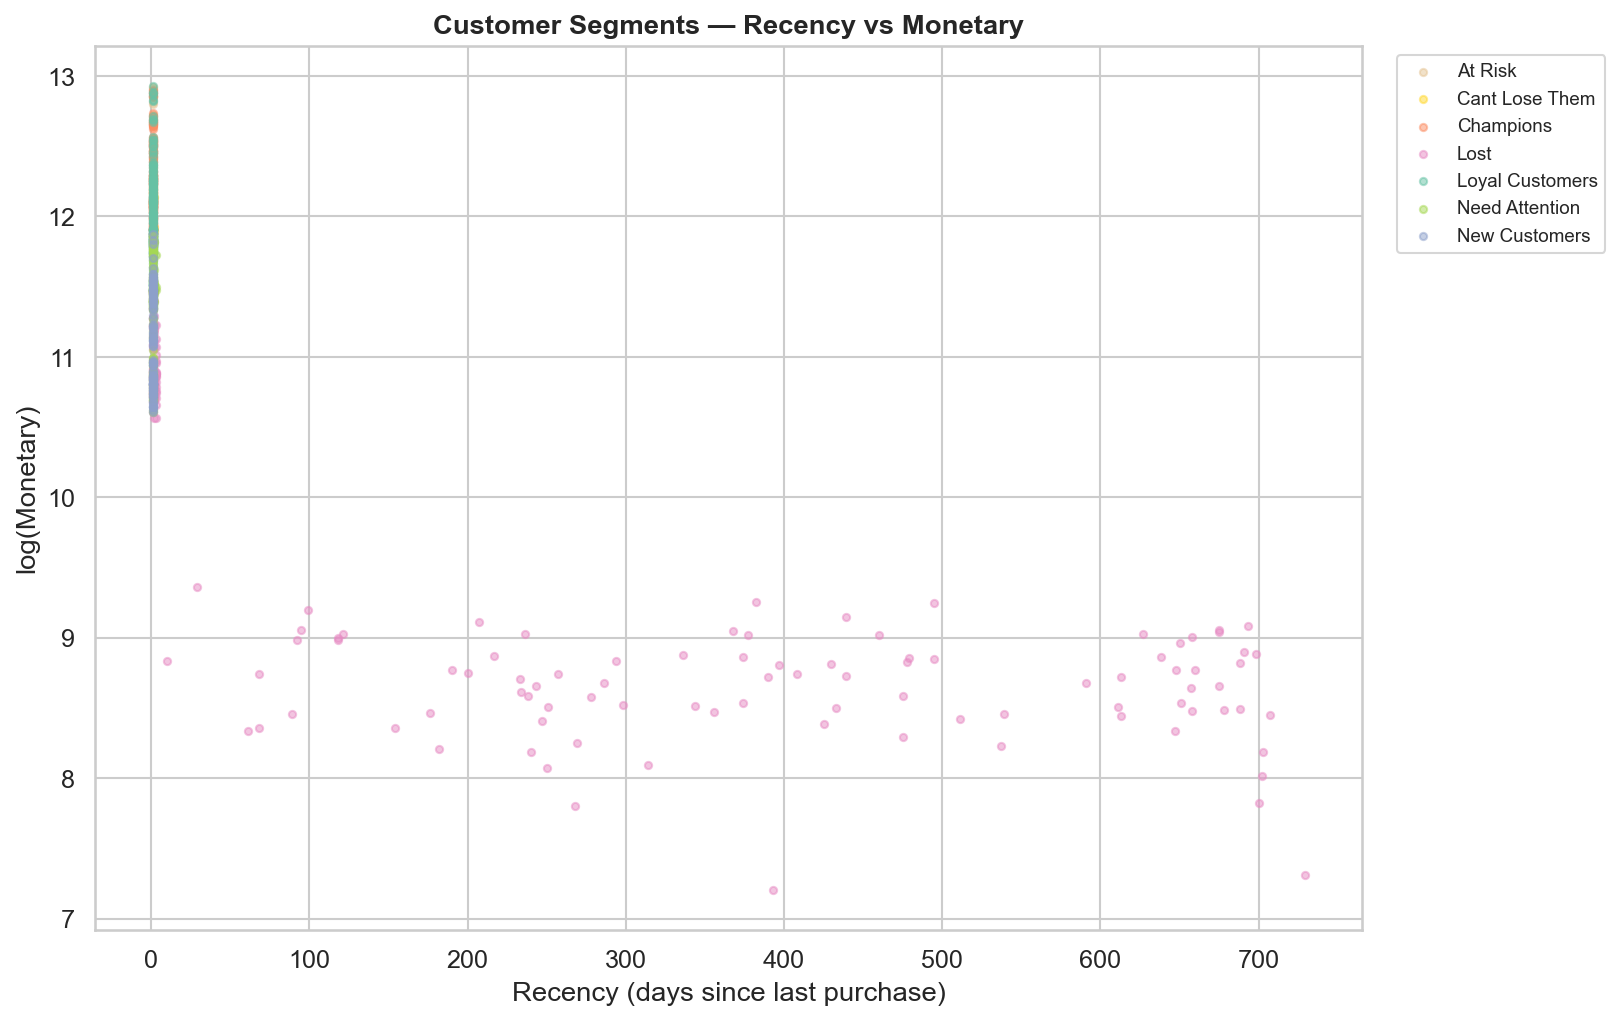

Saved: rfm_plot4_scatter.png


In [124]:
palette_map = {seg: sns.color_palette("Set2", len(rfm["segment"].unique()))[i]
               for i, seg in enumerate(rfm["segment"].unique())}

fig, ax = plt.subplots(figsize=(11, 7))
for seg, grp in rfm.groupby("segment"):
    ax.scatter(grp["recency"], np.log1p(grp["monetary"]),
               label=seg, alpha=0.5, s=12, color=palette_map[seg])
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("log(Monetary)")
ax.set_title("Customer Segments — Recency vs Monetary", fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT}rfm_plot4_scatter.png")
plt.show()
print("Saved: rfm_plot4_scatter.png")

In [125]:
# Business insight print

In [126]:
print("\n─── Business Insights ───────────────────────────────")
for seg in ["Champions", "Loyal Customers", "At Risk", "Lost", "New Customers"]:
    subset = rfm[rfm["segment"] == seg]
    if len(subset) == 0:
        continue
    print(f"[{seg}]  Customers: {len(subset):,}  |  "
          f"Avg Recency: {subset['recency'].mean():.0f}d  |  "
          f"Avg Spend: ${subset['monetary'].mean():,.0f}  |  "
          f"Avg Freq: {subset['frequency'].mean():.1f} txns")

print("\nStep 3 complete.")


─── Business Insights ───────────────────────────────
[Champions]  Customers: 168  |  Avg Recency: 1d  |  Avg Spend: $218,047  |  Avg Freq: 3087.2 txns
[Loyal Customers]  Customers: 224  |  Avg Recency: 1d  |  Avg Spend: $166,490  |  Avg Freq: 2447.3 txns
[At Risk]  Customers: 107  |  Avg Recency: 1d  |  Avg Spend: $216,509  |  Avg Freq: 3072.7 txns
[Lost]  Customers: 208  |  Avg Recency: 179d  |  Avg Spend: $36,680  |  Avg Freq: 482.0 txns
[New Customers]  Customers: 120  |  Avg Recency: 1d  |  Avg Spend: $70,017  |  Avg Freq: 985.7 txns

Step 3 complete.


In [127]:
# Time-Series Forecasting with Prophet

In [128]:
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight"})
OUTPUT = "outputs/"

In [129]:
df["trans_date"] = pd.to_datetime(df["trans_date"])
df_legit = df[df["is_fraud"] == 0].copy()
print(f"Legitimate transactions: {len(df_legit):,}")

Legitimate transactions: 1,842,743


In [130]:
# Total daily spend forecast (all customers)

In [131]:
print("\n─── Model A: Total Daily Spend ──────────────────────")

daily_spend = (df_legit.groupby("trans_date")["amt"]
                        .sum()
                        .reset_index()
                        .rename(columns={"trans_date":"ds","amt":"y"}))
daily_spend["ds"] = pd.to_datetime(daily_spend["ds"])

print(f"Time series length: {len(daily_spend)} days")
print(f"Date range: {daily_spend['ds'].min().date()} → {daily_spend['ds'].max().date()}")


─── Model A: Total Daily Spend ──────────────────────
Time series length: 730 days
Date range: 2019-01-01 → 2020-12-31


In [132]:
# Train model

In [133]:
m_spend = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_mode="multiplicative",
    interval_width=0.90
)
m_spend.fit(daily_spend)

23:04:43 - cmdstanpy - INFO - Chain [1] start processing
23:04:43 - cmdstanpy - INFO - Chain [1] done processing


In [134]:
# Forecast 90 days ahead

In [135]:
future_spend = m_spend.make_future_dataframe(periods=90)
forecast_spend = m_spend.predict(future_spend)

print("\nForecast sample (last 5 rows):")
print(forecast_spend[["ds","yhat","yhat_lower","yhat_upper"]].tail().to_string())


Forecast sample (last 5 rows):
            ds           yhat     yhat_lower     yhat_upper
815 2021-03-27  159121.269685   99675.900143  220181.750126
816 2021-03-28  210114.753533  152658.011391  267235.708119
817 2021-03-29  229384.965041  169958.490988  290427.793390
818 2021-03-30  159630.736936  102962.328282  220628.677938
819 2021-03-31  100145.417017   46890.936311  154318.094724


In [136]:
# Forecast

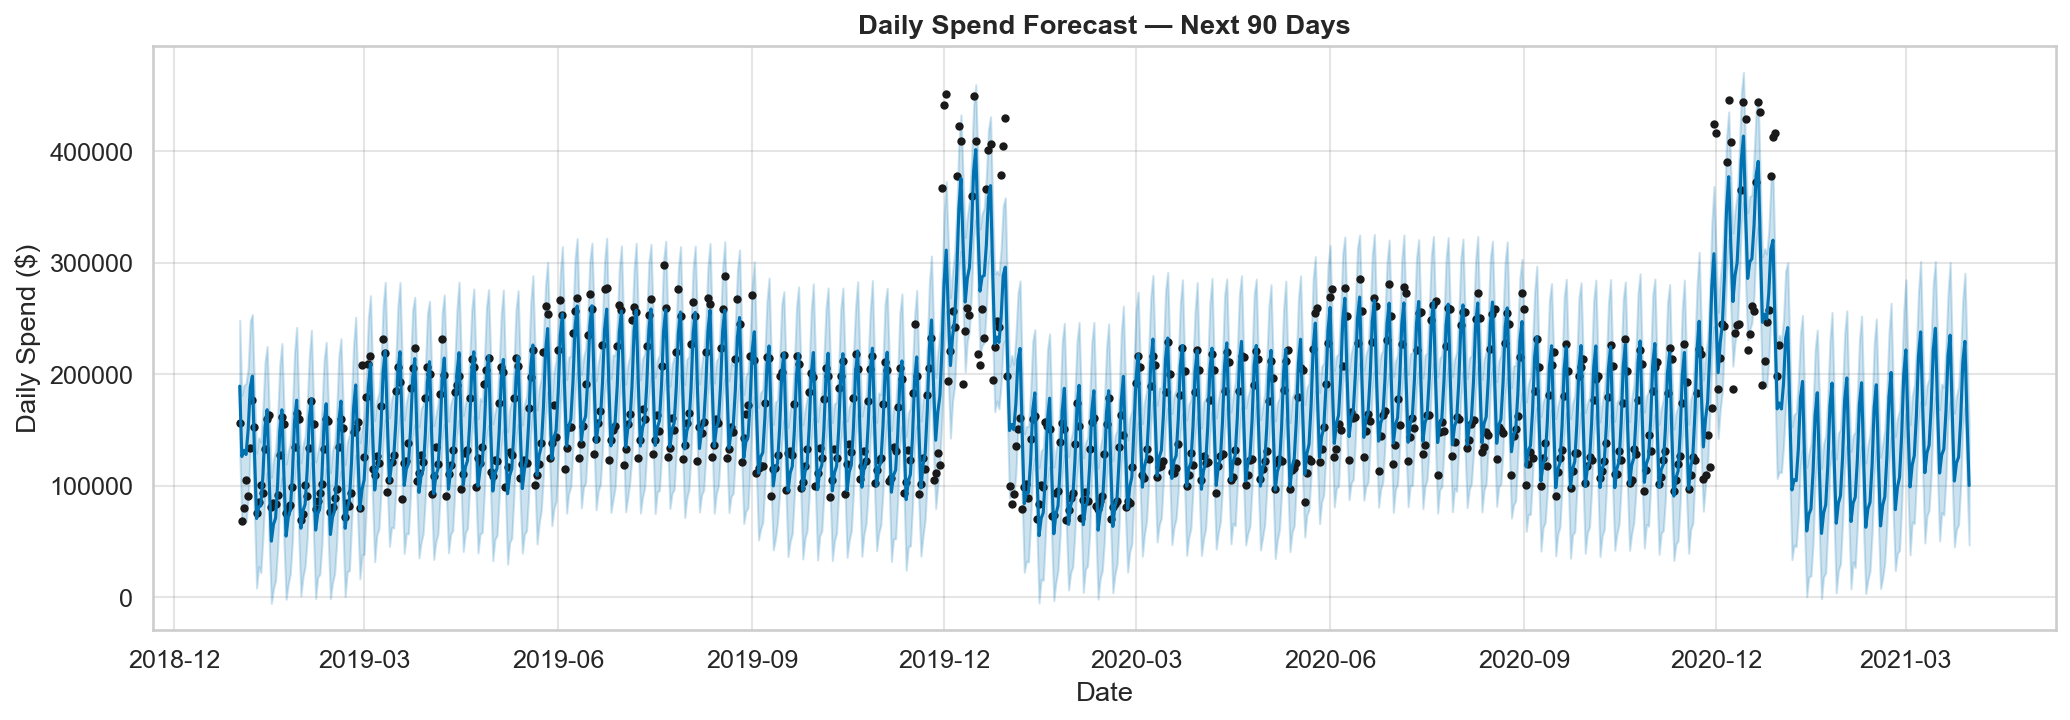

Saved: prophet_A1_forecast.png


In [137]:
fig = m_spend.plot(forecast_spend, figsize=(14, 5))
plt.title("Daily Spend Forecast — Next 90 Days", fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Daily Spend ($)")
plt.tight_layout()
plt.savefig(f"{OUTPUT}prophet_A1_forecast.png")
plt.show()
print("Saved: prophet_A1_forecast.png")

In [138]:
# Components

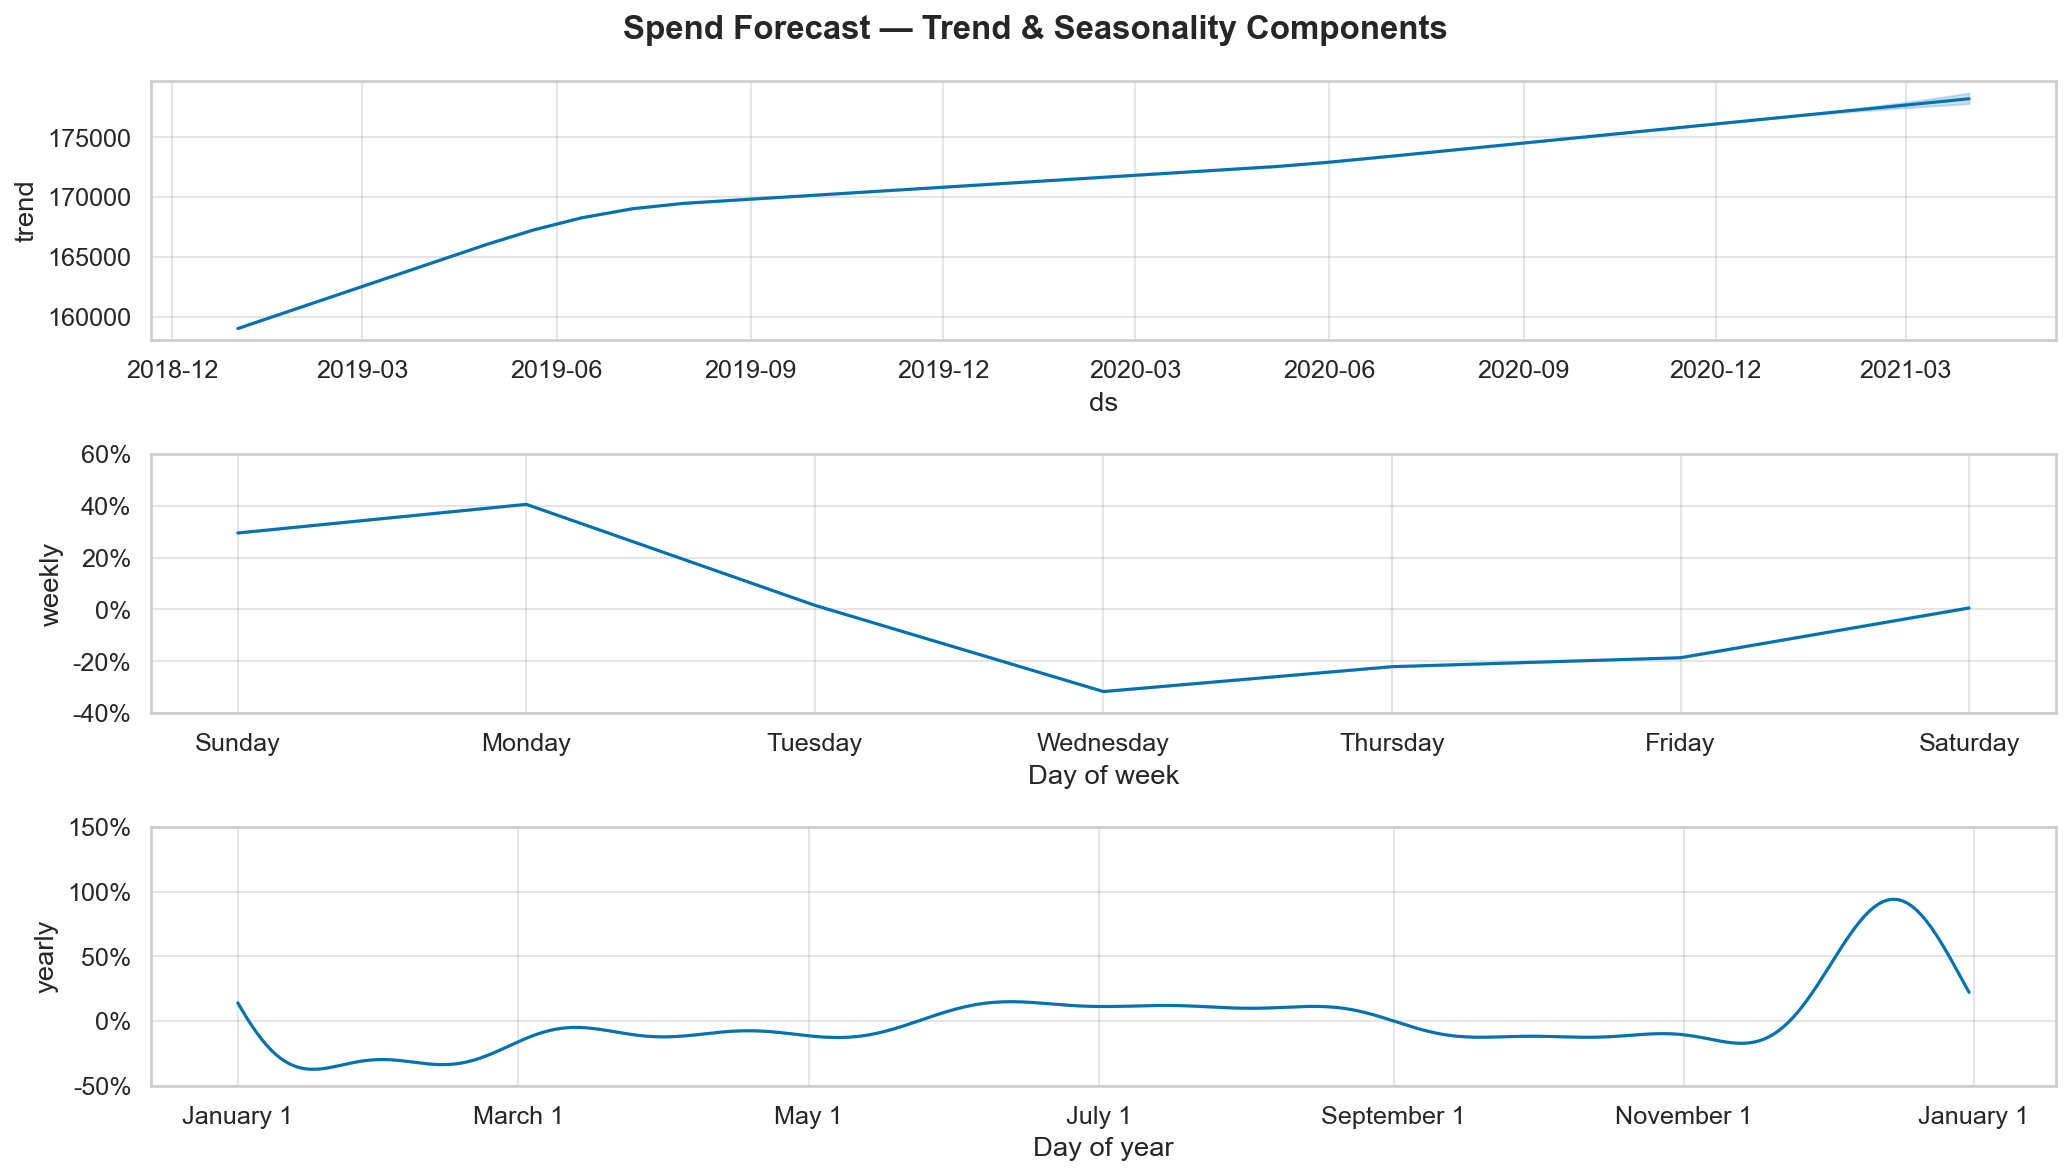

Saved: prophet_A2_components.png


In [139]:
fig = m_spend.plot_components(forecast_spend, figsize=(14, 8))
plt.suptitle("Spend Forecast — Trend & Seasonality Components", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT}prophet_A2_components.png")
plt.show()
print("Saved: prophet_A2_components.png")

In [140]:
# Daily transaction volume (count) forecast


─── Model B: Daily Transaction Count ────────────────


23:04:47 - cmdstanpy - INFO - Chain [1] start processing
23:04:47 - cmdstanpy - INFO - Chain [1] done processing


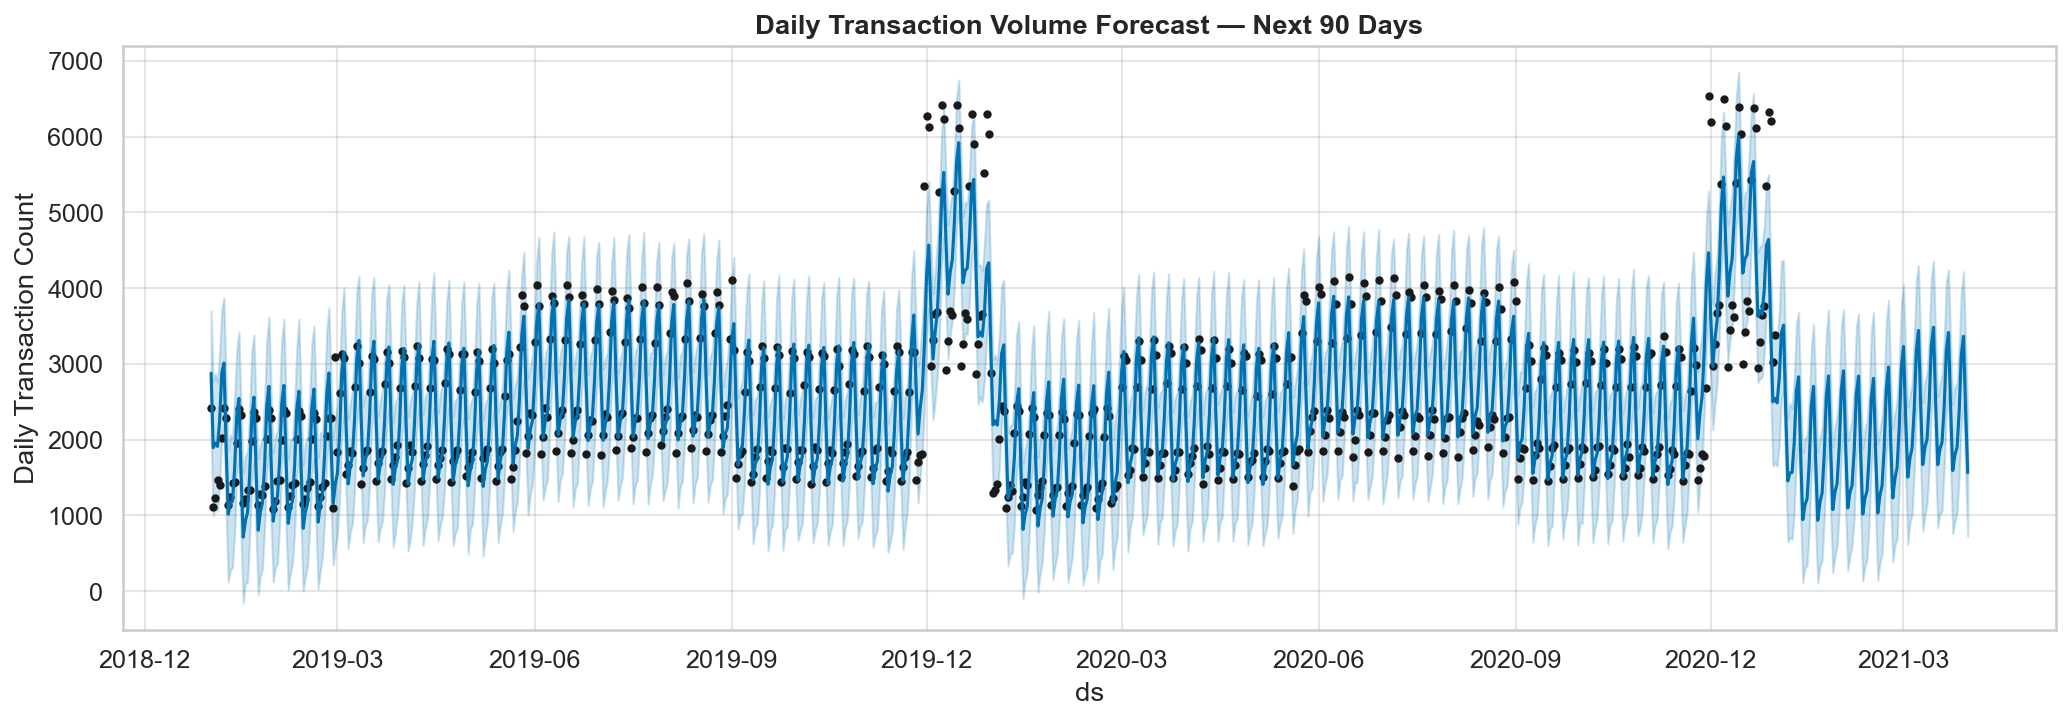

Saved: prophet_B1_count_forecast.png


In [141]:
print("\n─── Model B: Daily Transaction Count ────────────────")

daily_count = (df_legit.groupby("trans_date")["amt"]
                        .count()
                        .reset_index()
                        .rename(columns={"trans_date":"ds","amt":"y"}))
daily_count["ds"] = pd.to_datetime(daily_count["ds"])

m_count = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.1,
    interval_width=0.90
)
m_count.fit(daily_count)

future_count   = m_count.make_future_dataframe(periods=90)
forecast_count = m_count.predict(future_count)

fig = m_count.plot(forecast_count, figsize=(14, 5))
plt.title("Daily Transaction Volume Forecast — Next 90 Days", fontweight="bold")
plt.ylabel("Daily Transaction Count")
plt.tight_layout()
plt.savefig(f"{OUTPUT}prophet_B1_count_forecast.png")
plt.show()
print("Saved: prophet_B1_count_forecast.png")

In [142]:
#  MODEL C — Per-segment forecast (Champions vs At Risk)


─── Model C: Segment-level Forecast ─────────────────


23:04:50 - cmdstanpy - INFO - Chain [1] start processing
23:04:50 - cmdstanpy - INFO - Chain [1] done processing
23:04:51 - cmdstanpy - INFO - Chain [1] start processing
23:04:51 - cmdstanpy - INFO - Chain [1] done processing


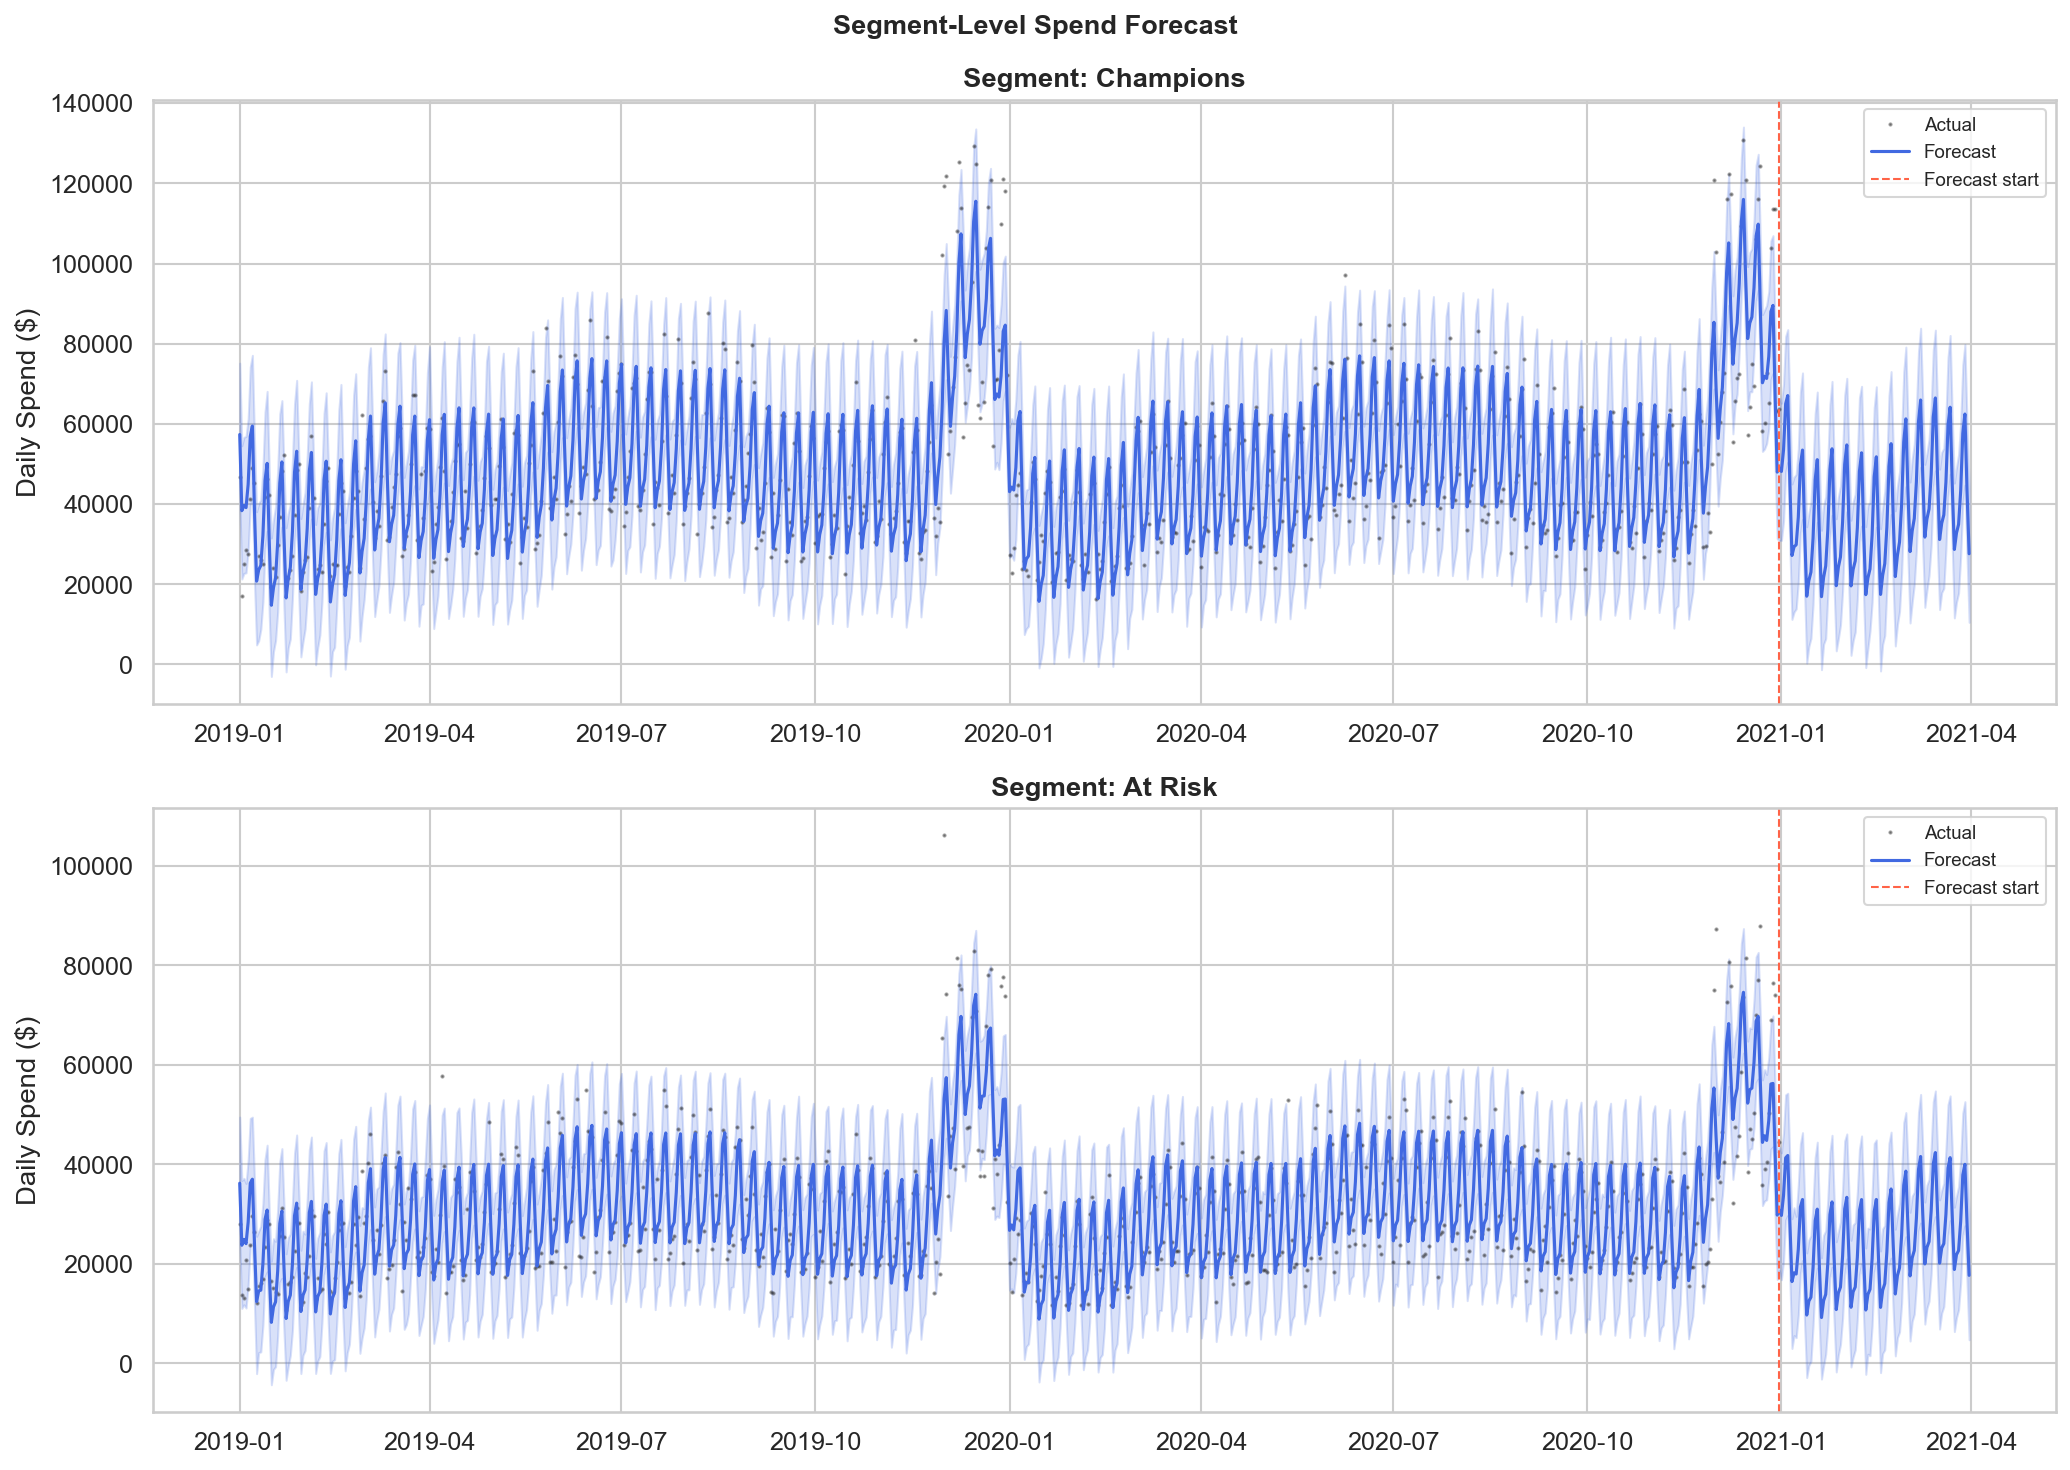

Saved: prophet_C1_segment_forecast.png


In [143]:
print("\n─── Model C: Segment-level Forecast ─────────────────")

rfm_file = f"{OUTPUT}rfm_table.csv"
try:
    rfm = pd.read_csv(rfm_file)
    rfm.rename(columns={"customer_id":"cc_num"}, inplace=True)

    df_seg = df_legit.merge(rfm[["cc_num","segment"]], on="cc_num", how="inner")

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    for ax, seg in zip(axes, ["Champions", "At Risk"]):
        seg_daily = (df_seg[df_seg["segment"] == seg]
                     .groupby("trans_date")["amt"]
                     .sum()
                     .reset_index()
                     .rename(columns={"trans_date":"ds","amt":"y"}))
        seg_daily["ds"] = pd.to_datetime(seg_daily["ds"])

        if len(seg_daily) < 30:
            ax.text(0.5, 0.5, f"Not enough data for '{seg}'",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"{seg} — Insufficient Data")
            continue

        m = Prophet(weekly_seasonality=True, yearly_seasonality=True,
                    interval_width=0.90, changepoint_prior_scale=0.05)
        m.fit(seg_daily)
        future = m.make_future_dataframe(periods=90)
        fc     = m.predict(future)

        ax.plot(seg_daily["ds"], seg_daily["y"], "k.", markersize=2, alpha=0.4, label="Actual")
        ax.plot(fc["ds"], fc["yhat"], color="royalblue", linewidth=1.5, label="Forecast")
        ax.fill_between(fc["ds"], fc["yhat_lower"], fc["yhat_upper"],
                        alpha=0.2, color="royalblue")
        ax.axvline(seg_daily["ds"].max(), color="tomato", linestyle="--",
                   linewidth=1, label="Forecast start")
        ax.set_title(f"Segment: {seg}", fontweight="bold")
        ax.set_ylabel("Daily Spend ($)")
        ax.legend(fontsize=9)

    plt.suptitle("Segment-Level Spend Forecast", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT}prophet_C1_segment_forecast.png")
    plt.show()
    print("Saved: prophet_C1_segment_forecast.png")

except FileNotFoundError:
    print("RFM table not found — run step3_rfm_segmentation.py first to get segment forecast.")

In [144]:
#  Summary table — 30 / 60 / 90 day projected spend

In [145]:
last_actual = daily_spend["ds"].max()
proj_30  = forecast_spend[forecast_spend["ds"] > last_actual].head(30)["yhat"].sum()
proj_60  = forecast_spend[forecast_spend["ds"] > last_actual].head(60)["yhat"].sum()
proj_90  = forecast_spend[forecast_spend["ds"] > last_actual].head(90)["yhat"].sum()

print("\n─── Projected Revenue Summary ───────────────────────")
print(f"  Next 30 days : ${proj_30:,.0f}")
print(f"  Next 60 days : ${proj_60:,.0f}")
print(f"  Next 90 days : ${proj_90:,.0f}")


─── Projected Revenue Summary ───────────────────────
  Next 30 days : $3,903,322
  Next 60 days : $7,812,979
  Next 90 days : $12,643,276


In [146]:
# Save forecast CSV


In [147]:
forecast_spend[["ds","yhat","yhat_lower","yhat_upper"]].to_csv(
    f"{OUTPUT}forecast_daily_spend.csv", index=False)
print(f"\nForecast saved → {OUTPUT}forecast_daily_spend.csv")


Forecast saved → outputs/forecast_daily_spend.csv
